# Fashion-MNIST — Multi-Class Image Classification with a Hand-Written KNN

**Machine Learning Assignment — Computer Vision track**

## Students

| Name | ID (last 4 digits) |
|---|---|
| Moran K. | 5348 |
| Ariel K. | 2441 |

## Dataset

**Fashion-MNIST** (Zalando Research) — <https://www.kaggle.com/datasets/zalando-research/fashionmnist>

# Part 1 — The learning problem and the dataset

Fashion-MNIST contains 70,000 greyscale photographs of clothing items produced by
Zalando, each one 28×28 pixels — 784 pixel values in the range 0–255. Every image
belongs to exactly one of **10 categories** (T-shirt/top, Trouser, Pullover, Dress,
Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot), which makes this a **multi-class
classification** problem: the input is an image and the output is one of ten labels.
The data ships already split into 60,000 training rows and 10,000 test rows, stored
as CSV files whose first column is the label and whose remaining 784 columns are the
flattened pixels. The classes are perfectly balanced — 6,000 training images each —
so there is no majority class to focus on, and accuracy alone would hide which
categories the model confuses. We therefore score the model with **macro-average F1**:
the F1 score is computed separately for each of the ten classes and then averaged
without weighting, so a model that handles nine categories well and one badly cannot
hide behind the majority.

The difficulty of the dataset is concentrated in the upper-body garments. T-shirt,
Pullover, Coat and Shirt occupy almost the same silhouette at 28×28 resolution, and
we expect most of the remaining error to sit in that group.

**Our approach.** We implement a **K-Nearest-Neighbours classifier** from scratch in
NumPy. KNN instance-based learner: training only memorises the data, and
a prediction is made by finding the k training images closest to the query image and
letting them vote. Because a raw distance over 784 correlated pixels is both slow and
noisy, we first apply feature engineering — pixel scaling followed by PCA — and we
tune the whole pipeline with a grid search wrapped in 5-fold cross-validation.

### How this notebook is organised

Everything runs from this single notebook — the configuration, the data loading, the
feature engineering, the KNN classifier itself, the grid search and every figure are
all defined in the cells below. There is no project module to open alongside it, so
the code that produced each output is always visible right above that output.

| Part | Contents | Assignment |
|---|---|---|
| 1 | The problem, the data, the quality metric | Part 1 |
| 2 | Feature engineering — scaling and PCA | Part 2 |
| 3 | The KNN classifier, written from scratch | Part 3 |
| 4 | Grid search with 5-fold cross-validation | Part 6a (bonus) |
| 5 | Training the winning configuration on all the data | Part 4 |
| 6 | Prediction and evaluation on the test set | Part 5 |
| 7 | Explainability — why each prediction was made | Part 6c (bonus) |


### Setup and the settings this part needs

Imports, the paths, and the facts about the dataset itself. The only tunable knob
here is `MAX_TRAIN_SAMPLES`: `None` uses all 60,000 training rows, while a value like
`5000` gives a fast development run. The settings for feature engineering, for the
classifier and for the search appear later, each one in the part that uses it.

In [2]:
import itertools
import time
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
# Non-interactive backend: figures are written to disk, never opened in a window.
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from IPython.display import Image, display
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

# --- Paths -------------------------------------------------------------------
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"

TRAIN_CSV = DATA_DIR / "fashion-mnist_train.csv"
TEST_CSV = DATA_DIR / "fashion-mnist_test.csv"
KAGGLE_ZIP = PROJECT_ROOT / "archive.zip"

# --- Dataset -----------------------------------------------------------------
IMAGE_SIZE = 28
N_PIXELS = IMAGE_SIZE * IMAGE_SIZE
N_CLASSES = 10

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

# --- Sub-sampling ------------------------------------------------------------
# KNN cost grows with the number of training samples. None uses all 60,000
MAX_TRAIN_SAMPLES = None
MAX_TEST_SAMPLES = None

# Fixes every random choice in the notebook: the sub-sampling, the PCA solver
# and the cross-validation folds.
RANDOM_SEED = 42

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Classes        :", N_CLASSES, "->", CLASS_NAMES)

Classes        : 10 -> ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### Loading the two pre-split files

The train and test CSVs are loaded exactly as Kaggle provides them. the test file is opened only at the very end, for the
final evaluation.

If the CSVs are not in `data/` yet, `load_csv` extracts them from the Kaggle
`archive.zip` in the project root, so the notebook can set up its own data.

In [2]:
def extract_from_kaggle_zip(path):
    'Pull one CSV out of the Kaggle archive when it is missing from data/.'
    if not KAGGLE_ZIP.exists():
        return False
    with zipfile.ZipFile(KAGGLE_ZIP) as z:
        if path.name not in z.namelist():
            return False
        DATA_DIR.mkdir(parents=True, exist_ok=True)
        z.extract(path.name, DATA_DIR)
        print(f"extracted {path.name} from {KAGGLE_ZIP.name}")
    return True


def load_csv(path):
    'Read one Fashion-MNIST CSV (first column label, then 784 pixel columns).'
    if not path.exists() and not extract_from_kaggle_zip(path):
        raise FileNotFoundError(
            f"Dataset file not found: {path}\n"
            "Download the dataset from "
            "https://www.kaggle.com/datasets/zalando-research/fashionmnist "
            f"and place archive.zip in {PROJECT_ROOT}, or put the CSVs in {DATA_DIR}"
        )
    return pd.read_csv(path)


def frame_to_xy(df):
    'Split a raw dataframe into a float pixel matrix X and an integer label vector y.'
    y = df["label"].to_numpy(dtype=np.int64)
    X = df.drop(columns=["label"]).to_numpy(dtype=np.float64)
    return X, y


def stratified_subsample(X, y, max_samples, seed=RANDOM_SEED):
    'Take at most max_samples rows while preserving the class distribution.'
    # This is a size reduction, not a train/test split: the official train and
    # test files stay separate and are never merged or re-split.
    if max_samples is None or max_samples >= len(y):
        return X, y

    rng = np.random.default_rng(seed)
    classes, counts = np.unique(y, return_counts=True)
    # Largest-remainder allocation keeps the subset proportional to the original.
    exact = counts / counts.sum() * max_samples
    quota = np.floor(exact).astype(int)
    for idx in np.argsort(-(exact - quota))[: max_samples - quota.sum()]:
        quota[idx] += 1

    selected = []
    for cls, n_take in zip(classes, quota):
        cls_idx = np.flatnonzero(y == cls)
        selected.append(rng.choice(cls_idx, size=min(n_take, cls_idx.size), replace=False))

    keep = np.sort(np.concatenate(selected))
    return X[keep], y[keep]


def class_distribution(y):
    'Per-class counts and shares, used to check whether the data is balanced.'
    classes, counts = np.unique(y, return_counts=True)
    return pd.DataFrame({
        "label": classes,
        "class_name": [CLASS_NAMES[c] for c in classes],
        "count": counts,
        "share": counts / counts.sum(),
    })

In [3]:
train_df = load_csv(TRAIN_CSV)
test_df = load_csv(TEST_CSV)

print(f"train set: {train_df.shape[0]:,} rows x {train_df.shape[1]} columns")
print(f"test  set: {test_df.shape[0]:,} rows x {test_df.shape[1]} columns")
print("\nFirst 5 rows of the TRAIN set:")
train_df.head()

train set: 60,000 rows x 785 columns
test  set: 10,000 rows x 785 columns

First 5 rows of the TRAIN set:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,...,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,0,0,105,92,101,...,214,163,146,165,79,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,0,114,183,112,55,...,69,52,45,74,39,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,0,0,0,46,0,...,147,144,121,102,63,0,0,0,0,0,0,0,0,0,0


In [4]:
print("First 5 rows of the TEST set:")
test_df.head()

First 5 rows of the TEST set:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,...,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,0,0,34,29,7,...,138,142,145,135,125,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,209,190,181,...,155,0,65,235,216,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,17,0,0,0,0,...,0,0,0,0,0,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,161,212,138,150,169,...,146,137,141,143,137,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,0,37,0,0,0,...,0,2,69,0,2,0,0,0,0,0,0,0,0,0,0


### The quality metric

Macro-average F1 - we define it
once here and reuse it everywhere:
inside the cross-validation and on the final test
set. `f1_score` from scikit-learn is used as a utility, the classifier itself is
entirely our own.

F1 is the harmonic mean of precision and recall. The macro average computes it
separately for each of the ten classes and then takes a plain mean, so every class
carries equal weight regardless of its size and a strong class cannot compensate for
a weak one.

In [5]:
def macro_f1(y_true, y_pred):
    'Unweighted mean of the per-class F1 scores; every class counts equally.'
    return float(f1_score(y_true, y_pred, average="macro", zero_division=0))


def summary_scores(y_true, y_pred):
    'Headline macro-F1 plus two reference numbers for context.'
    return {
        "macro_f1": macro_f1(y_true, y_pred),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }


def per_class_report(y_true, y_pred):
    'Precision / recall / F1 per class as a dataframe.'
    report = classification_report(
        y_true, y_pred,
        labels=list(range(N_CLASSES)),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame([
        {
            "class_name": name,
            "precision": report[name]["precision"],
            "recall": report[name]["recall"],
            "f1": report[name]["f1-score"],
            "support": int(report[name]["support"]),
        }
        for name in CLASS_NAMES
    ])

### Figure helpers

Three small plotting functions used throughout the notebook. Figures are always
written to `outputs/figures/` and then displayed inline, so the notebook keeps its
visuals when it is opened without re-running.

In [6]:
def plot_image_grid(X, y, titles=None, n_cols=5, filename="samples.png", suptitle=None):
    'Render flat 784-value rows back into a grid of 28x28 images.'
    n = len(X)
    n_rows = int(np.ceil(n / n_cols))

    # Reserve vertical room for the tallest title, so multi-line captions on one
    # row cannot overlap the images on the row above.
    title_lines = max((t.count("\n") + 1 for t in titles), default=1) if titles else 1
    row_height = 2.0 + 0.22 * title_lines

    # Constrained layout accounts for titles and the suptitle when placing axes;
    # tight_layout does not, and lets them collide once titles wrap.
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(2.0 * n_cols, row_height * n_rows), layout="constrained"
    )
    axes = np.atleast_1d(axes).ravel()

    for i, ax in enumerate(axes):
        ax.axis("off")
        if i >= n:
            continue
        ax.imshow(X[i].reshape(IMAGE_SIZE, IMAGE_SIZE), cmap="gray")
        ax.set_title(titles[i] if titles else CLASS_NAMES[y[i]], fontsize=8)

    if suptitle:
        fig.suptitle(suptitle, fontsize=12)
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=150)
    plt.close(fig)
    return path


def plot_confusion_matrix(y_true, y_pred, filename="confusion_matrix.png", normalize=True):
    'Row-normalised confusion matrix over the ten classes.'
    cm = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))
    grid = cm.astype(float)
    if normalize:
        row_sums = grid.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        grid /= row_sums

    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(grid, cmap="Blues")
    fig.colorbar(im, ax=ax, fraction=0.046)

    ax.set_xticks(range(N_CLASSES), CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticks(range(N_CLASSES), CLASS_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Confusion matrix" + (" (row-normalised)" if normalize else ""))

    threshold = grid.max() / 2.0
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            text = f"{grid[i, j]:.2f}" if normalize else f"{int(grid[i, j])}"
            ax.text(j, i, text, ha="center", va="center", fontsize=7,
                    color="white" if grid[i, j] > threshold else "black")

    path = FIGURES_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)
    return path


def plot_per_class_f1(report_df, filename="per_class_f1.png"):
    'Horizontal bar chart of per-class F1, weakest class at the bottom.'
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ordered = report_df.sort_values("f1")
    ax.barh(ordered["class_name"], ordered["f1"], color="steelblue")
    ax.set_xlim(0, 1)
    ax.set_xlabel("F1 score")
    ax.set_title("Per-class F1 on the test set")
    for y_pos, value in enumerate(ordered["f1"]):
        ax.text(value + 0.01, y_pos, f"{value:.3f}", va="center", fontsize=8)

    path = FIGURES_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)
    return path

### Class balance

Both splits are perfectly balanced, which confirms that macro-F1 (rather than a
single-class F1) is the right metric: there is no "central" class to single out.

In [7]:
X_train_raw_full, y_train_full = frame_to_xy(train_df)
X_test_raw, y_test = frame_to_xy(test_df)

# MAX_TEST_SAMPLES only shrinks the test set for a fast development run; it is
# None for the real evaluation, which scores all 10,000 rows.
X_test_raw, y_test = stratified_subsample(X_test_raw, y_test, MAX_TEST_SAMPLES)

dist_train = class_distribution(y_train_full).rename(
    columns={"count": "train_count", "share": "train_share"})
dist_test = class_distribution(y_test)[["label", "count", "share"]].rename(
    columns={"count": "test_count", "share": "test_share"})
dist_train.merge(dist_test, on="label")

,label,class_name,train_count,train_share,test_count,test_share
0,0,T-shirt/top,6000,0.1,1000,0.1
1,1,Trouser,6000,0.1,1000,0.1
2,2,Pullover,6000,0.1,1000,0.1
3,3,Dress,6000,0.1,1000,0.1
4,4,Coat,6000,0.1,1000,0.1
5,5,Sandal,6000,0.1,1000,0.1
6,6,Shirt,6000,0.1,1000,0.1
7,7,Sneaker,6000,0.1,1000,0.1
8,8,Bag,6000,0.1,1000,0.1
9,9,Ankle boot,6000,0.1,1000,0.1


saved: C:\Users\asqwe\Desktop\MLMLML\outputs\figures\class_examples.png


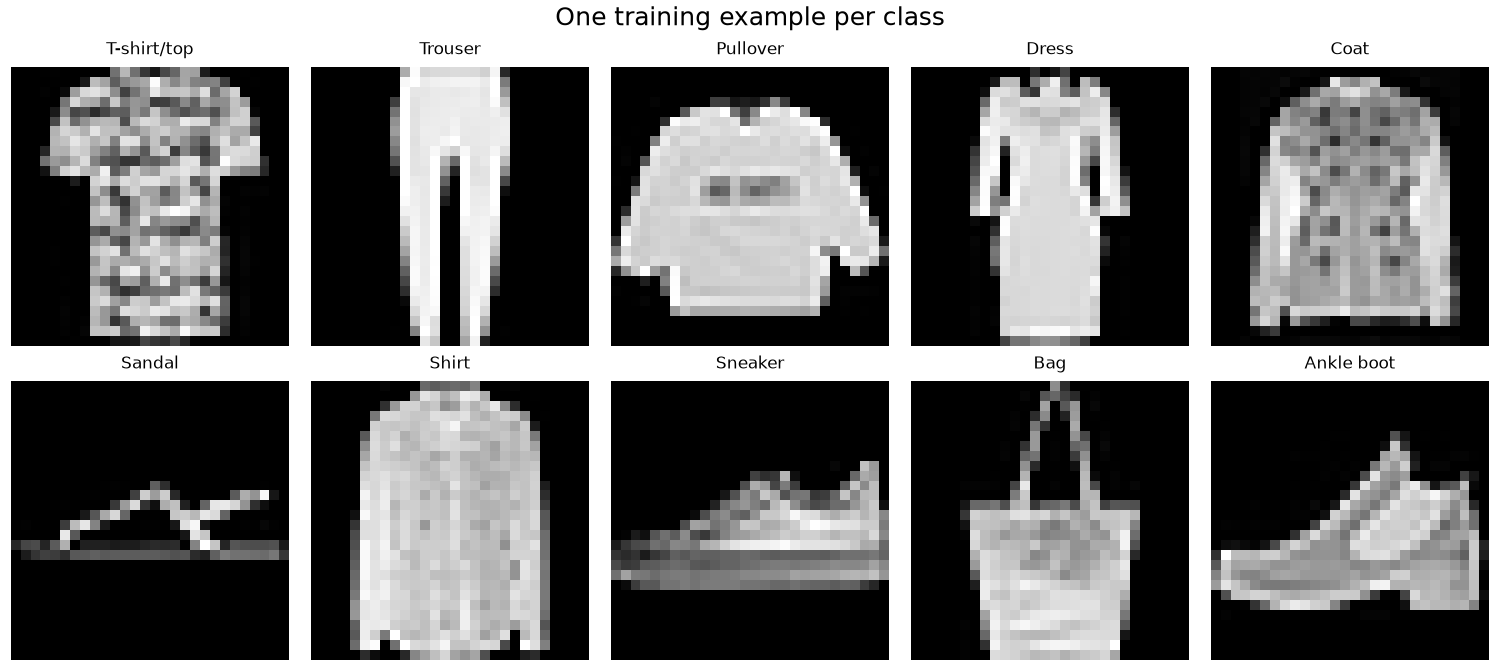

In [8]:
# One example image per class, straight from the raw pixel values.
first_of_each = [int(np.flatnonzero(y_train_full == c)[0]) for c in range(N_CLASSES)]
path = plot_image_grid(
    X_train_raw_full[first_of_each],
    y_train_full[first_of_each],
    n_cols=5,
    filename="class_examples.png",
    suptitle="One training example per class",
)
print("saved:", path)
display(Image(filename=str(path)))

### Working sample size

KNN compares every query against every stored training row, so its cost grows with
the size of the training set. `MAX_TRAIN_SAMPLES` caps the number of training rows
used, which lets us iterate quickly on 5,000 samples and then re-run everything at
full size by setting it to `None`. The subset is **stratified**, so the class balance
is preserved — this is a size reduction, not a second train/test split.

In [9]:
X_train_raw, y_train = stratified_subsample(
    X_train_raw_full, y_train_full, MAX_TRAIN_SAMPLES)

print(f"MAX_TRAIN_SAMPLES = {MAX_TRAIN_SAMPLES}")
print(f"training rows in use: {len(y_train):,} of {len(y_train_full):,}")
print(f"test rows in use    : {len(y_test):,}")
print("\nclass counts in the working training set:")
print(np.bincount(y_train, minlength=N_CLASSES))

MAX_TRAIN_SAMPLES = None
training rows in use: 60,000 of 60,000
test rows in use    : 10,000

class counts in the working training set:
[6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


---
# Part 2 — Feature engineering

*Answers assignment part 2.*

A raw Fashion-MNIST row is a 784-dimensional vector of integers in 0–255. Feeding
that straight into a distance-based classifier has two problems:

1. **Scale.** Distances are dominated by whichever pixels happen to have large
   values, and the 0–255 range makes the squared terms in the Euclidean distance
   large and numerically awkward.
2. **Dimensionality.** Neighbouring pixels in an image are strongly correlated, so
   the 784 dimensions carry far less than 784 dimensions' worth of information. In
   high dimensions distances also *concentrate* — everything becomes roughly
   equidistant from everything else — which is exactly the regime where KNN degrades.

We therefore apply two transformations, in order:

**Step 1 — pixel scaling.** Either
*min–max* scaling, $x' = (x - \min)/(\max - \min)$, which maps every pixel into
$[0, 1]$ and preserves the relative brightness structure of the image; or
*standardisation*, $x' = (x - \mu)/\sigma$, which centres every pixel at zero and
gives it unit variance, so rarely-lit border pixels get as much say as the
always-lit central pixels.

**Step 2 — PCA.** Principal Component Analysis rotates the data onto the directions
of greatest variance and keeps only the first `n` of them. This compresses 784
correlated pixels into a few dozen uncorrelated components, which both speeds up
every distance computation and removes most of the pixel noise.

**No leakage.** The scaler's min/max (or mean/std) and the PCA rotation are all
estimated on **training rows only**. The test rows are pushed through the already-
fitted transformation, so no statistic derived from the test set ever influences the
model. Inside the cross-validation this is applied even more strictly: the pipeline
is re-fitted on each fold's training part, never on the held-out validation part.

The scalers below are written by hand; `PCA` is taken from scikit-learn as a utility.
`FeaturePipeline` bundles the two into a single `fit` / `transform` unit so that the
"fit on train, apply to test" rule is enforced by construction rather than by
remembering to do it.

In [3]:
# --- Settings for this part --------------------------------------------------
# The defaults used for the illustrations below. The search in part 4 decides
# what the final model actually uses.
DEFAULT_SCALING = "minmax"      # one of: "none", "minmax", "standard"
DEFAULT_PCA_COMPONENTS = 50     # None disables PCA

# defined here because the variance curve at the end of this part marks them.
PCA_CANDIDATES = [30, 50, 100]

In [11]:
class MinMaxScaler:
    'Scale each pixel to [0, 1] using the training range.'

    def fit(self, X):
        self.min_ = X.min(axis=0)
        span = X.max(axis=0) - self.min_
        # Constant pixels (always 0 in the corners) would divide by zero.
        self.scale_ = np.where(span == 0, 1.0, span)
        return self

    def transform(self, X):
        return (X - self.min_) / self.scale_


class StandardScaler:
    'Centre each pixel to zero mean and unit variance using training statistics.'

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        std = X.std(axis=0)
        self.scale_ = np.where(std == 0, 1.0, std)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.scale_


class IdentityScaler:
    'No scaling; keeps raw 0-255 pixel values.'

    def fit(self, X):
        return self

    def transform(self, X):
        return X


SCALERS = {
    "none": IdentityScaler,
    "minmax": MinMaxScaler,
    "standard": StandardScaler,
}


class FeaturePipeline:
    'Scaling + optional PCA, exposed as a single fit / transform unit.'

    def __init__(self, scaling=DEFAULT_SCALING, pca_components=DEFAULT_PCA_COMPONENTS,
                 seed=RANDOM_SEED):
        if scaling not in SCALERS:
            raise ValueError(f"Unknown scaling '{scaling}'. Choose from {sorted(SCALERS)}.")
        self.scaling = scaling
        self.pca_components = pca_components
        self.seed = seed
        self.scaler = None
        self.pca = None

    def fit(self, X):
        # Both the scaler statistics and the PCA basis come from X alone.
        self.scaler = SCALERS[self.scaling]().fit(X)
        Xs = self.scaler.transform(X)
        if self.pca_components:
            n = min(self.pca_components, Xs.shape[0], Xs.shape[1])
            self.pca = PCA(n_components=n, random_state=self.seed).fit(Xs)
        else:
            self.pca = None
        return self

    def transform(self, X):
        if self.scaler is None:
            raise RuntimeError("FeaturePipeline.fit must be called before transform.")
        Xs = self.scaler.transform(X)
        return self.pca.transform(Xs) if self.pca is not None else Xs

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    @property
    def explained_variance(self):
        'Share of training variance retained by PCA, or None when PCA is off.'
        return None if self.pca is None else float(self.pca.explained_variance_ratio_.sum())

    def inverse_transform(self, Z):
        'Map features back to pixel space, for visualising what PCA preserved.'
        if self.pca is not None:
            Z = self.pca.inverse_transform(Z)
        if self.scaling == "minmax":
            return Z * self.scaler.scale_ + self.scaler.min_
        if self.scaling == "standard":
            return Z * self.scaler.scale_ + self.scaler.mean_
        return Z

    def describe(self):
        pca_part = f"PCA({self.pca_components})" if self.pca_components else "no PCA"
        return f"scaling={self.scaling}, {pca_part}"

In [12]:
# Fit the default pipeline on the training rows only.
pipeline_demo = FeaturePipeline(
    scaling=DEFAULT_SCALING,
    pca_components=DEFAULT_PCA_COMPONENTS,
).fit(X_train_raw)

print("pipeline:", pipeline_demo.describe())
print(f"variance retained by PCA: {pipeline_demo.explained_variance:.2%}")
print(f"784 raw pixels -> {DEFAULT_PCA_COMPONENTS} components "
      f"({DEFAULT_PCA_COMPONENTS / N_PIXELS:.1%} of the original size)")

pipeline: scaling=minmax, PCA(50)
variance retained by PCA: 86.24%
784 raw pixels -> 50 components (6.4% of the original size)


### Following 3 training and 3 test examples through the pipeline

The assignment asks to show the feature engineering on a few concrete examples from
each split. Below, three training images and three test images are traced through
every stage: raw pixels → scaled pixels → PCA components. The **test** rows go
through the transformation that was fitted on the **training** rows.

The table reports what each stage does to the numbers, and the figure after it shows
the same thing as pictures — every image beside itself rebuilt from its components
via `inverse_transform`. Reading the components as raw coordinates would tell us
nothing (they are directions in a rotated space, not pixels), so we judge the
compression the way it is actually experienced: by what the image looks like
afterwards, and by the mean per-pixel error of rebuilding it.

In [13]:
def trace_examples(X_raw, y, idx, split_name, pipeline):
    'Summarise what each stage of the pipeline does to a few sample rows.'
    scaled = pipeline.scaler.transform(X_raw[idx])
    reduced = pipeline.transform(X_raw[idx])
    # Rebuilding the image from its components shows how much detail survived.
    rebuilt = pipeline.inverse_transform(reduced)
    rows = []
    for i, row_id in enumerate(idx):
        rows.append({
            "split": split_name,
            "row": row_id,
            "class": CLASS_NAMES[y[row_id]],
            "raw dims": X_raw[row_id].shape[0],
            "raw min/max": f"{X_raw[row_id].min():.0f} / {X_raw[row_id].max():.0f}",
            "scaled min/max": f"{scaled[i].min():.2f} / {scaled[i].max():.2f}",
            "pca dims": reduced.shape[1],
            "compression": f"{reduced.shape[1] / X_raw.shape[1]:.1%}",
            # Mean absolute error per pixel, back on the original 0-255 scale.
            "rebuild error/px": f"{np.abs(rebuilt[i] - X_raw[row_id]).mean():.1f}",
        })
    return pd.DataFrame(rows), scaled, reduced, rebuilt

train_idx = [0, 1, 2]
test_idx = [0, 1, 2]

tr_table, tr_scaled, tr_reduced, tr_rebuilt = trace_examples(
    X_train_raw, y_train, train_idx, "train", pipeline_demo)
te_table, te_scaled, te_reduced, te_rebuilt = trace_examples(
    X_test_raw, y_test, test_idx, "test", pipeline_demo)

pd.concat([tr_table, te_table], ignore_index=True)

,split,row,class,raw dims,raw min/max,scaled min/max,pca dims,compression,rebuild error/px
0,train,0,Pullover,784,0 / 255,0.00 / 1.00,50,6.4%,26.3
1,train,1,Ankle boot,784,0 / 255,0.00 / 1.00,50,6.4%,19.8
2,train,2,Shirt,784,0 / 255,0.00 / 1.00,50,6.4%,13.0
3,test,0,T-shirt/top,784,0 / 255,0.00 / 1.00,50,6.4%,18.4
4,test,1,Trouser,784,0 / 255,0.00 / 1.00,50,6.4%,12.9
5,test,2,Pullover,784,0 / 254,0.00 / 1.00,50,6.4%,14.3


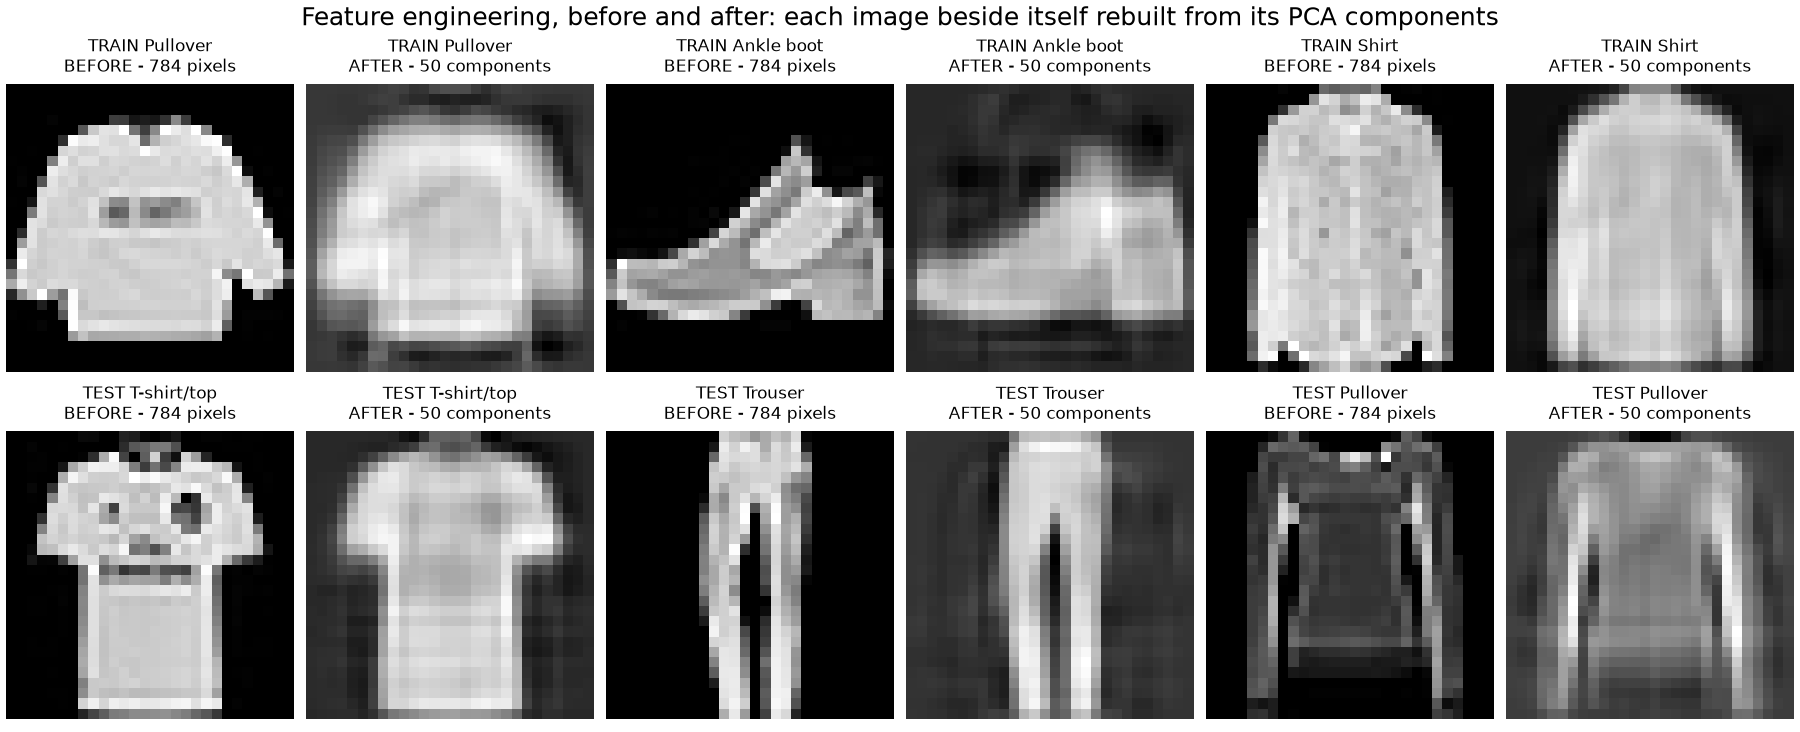

In [14]:
def pair_before_after(X_raw, rebuilt, y, idx, split_name):
    'Interleave each original image with its rebuilt version, plus matching titles.'
    images = np.empty((len(idx) * 2, X_raw.shape[1]))
    images[0::2] = X_raw[idx]      # before
    images[1::2] = rebuilt         # after
    titles = []
    for row_id in idx:
        name = CLASS_NAMES[y[row_id]]
        titles.append(f"{split_name} {name}\nBEFORE - 784 pixels")
        titles.append(f"{split_name} {name}\nAFTER - {DEFAULT_PCA_COMPONENTS} components")
    return images, titles

train_images, train_titles = pair_before_after(
    X_train_raw, tr_rebuilt, y_train, train_idx, "TRAIN")
test_images, test_titles = pair_before_after(
    X_test_raw, te_rebuilt, y_test, test_idx, "TEST")

# Each image sits directly next to its own reconstruction; row 1 is train, row 2 test.
path = plot_image_grid(
    np.vstack([train_images, test_images]),
    None,
    titles=train_titles + test_titles,
    n_cols=6,
    filename="feature_engineering_examples.png",
    suptitle="Feature engineering, before and after: each image beside itself "
             "rebuilt from its PCA components",
)
display(Image(filename=str(path)))

The reconstructions keep the silhouette and the broad shading of each garment while
dropping fine texture — which is precisely the trade we want. The information that
distinguishes a sandal from a pullover survives; the per-pixel noise does not.

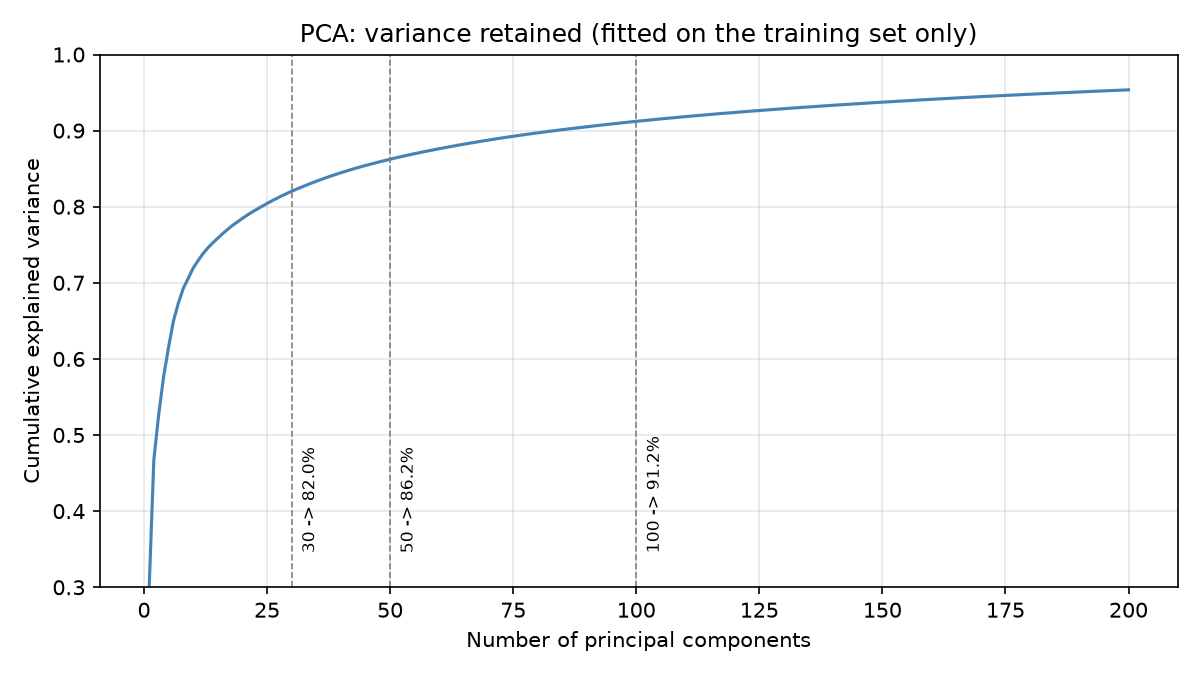

In [15]:
# How much variance each number of components retains.
full_pca = FeaturePipeline(DEFAULT_SCALING, 200).fit(X_train_raw)
cum = np.cumsum(full_pca.pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, len(cum) + 1), cum, color="steelblue")
for n in PCA_CANDIDATES:
    ax.axvline(n, color="grey", ls="--", lw=0.8)
    ax.text(n + 2, 0.35, f"{n} -> {cum[n - 1]:.1%}", fontsize=8, rotation=90)
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA: variance retained (fitted on the training set only)")
ax.set_ylim(0.3, 1.0)
ax.grid(alpha=0.3)
fig.tight_layout()
p = FIGURES_DIR / "pca_explained_variance.png"
fig.savefig(p, dpi=150)
plt.close(fig)
display(Image(filename=str(p)))

---
# Part 3 — The learning algorithm: KNN, implemented from scratch

*Answers assignment part 3.*

The complete classifier is defined in the cells below. Nothing here comes from a
ready-made classifier.

### How it works

KNN is a lazy learner. `fit(X, y)` estimates no parameters at all — it simply
stores the training matrix and the labels. All of the work happens at prediction
time:

1. For a query image, compute its distance to every stored training image.
2. Take the k smallest distances — the k nearest neighbours.
3. Let those k neighbours vote for their own class.
4. The class with the highest vote total is the prediction.

### Hyperparameters

| Hyperparameter | Values | What it controls |
|---|---|---|
| `k` | 1, 3, 5, 7 | How many neighbours vote. `k=1` copies the single closest image and follows the noise in the data (high variance); a large `k` smooths the decision boundary but starts to blur genuinely small classes (high bias). |
| `metric` | `euclidean`, `manhattan`, `cosine` | How "close" is measured. **Euclidean** is straight-line distance, $\sqrt{\sum (a_i - b_i)^2}$. **Manhattan** sums absolute differences, $\sum \lvert a_i - b_i \rvert$, and reacts less violently to one very different pixel. **Cosine** measures the angle between the two vectors and ignores their magnitude, so an overall brighter photo of the same garment stays close. |
| `weights` | `uniform`, `distance` | How votes are counted. `uniform` gives every one of the k neighbours a single vote; `distance` weights each vote by $1/d$, so a neighbour sitting right on top of the query outweighs one at the edge of the neighbourhood. |

### The three distance functions

Each one takes a block of query rows `A` and the stored training rows `B`, and
returns the full `len(A) × len(B)` matrix of distances between them.

* **Vectorised distances.** The Euclidean matrix is never built with a Python loop.
  We use the expansion $\lVert a-b \rVert^2 = \lVert a \rVert^2 + \lVert b \rVert^2 - 2\,a\!\cdot\!b$,
  which turns the whole distance matrix into one matrix multiplication.
* Manhattan cannot be written as a matrix product, so it is built in row blocks that
  bound how large the temporary array is allowed to grow.
* Cosine normalises both sides to unit length first, which is what makes it blind to
  overall image brightness.

In [16]:
# --- Settings for this part --------------------------------------------------
# Defaults for the classifier. Part 4 searches over all of these; the values
# here are only what you get when a KNNClassifier is built without arguments.
DEFAULT_K = 5
DEFAULT_METRIC = "euclidean"    # one of: "euclidean", "manhattan", "cosine"
DEFAULT_WEIGHTS = "uniform"     # one of: "uniform", "distance"

# Query rows scored per block inside predict. Larger values are faster but
# allocate a bigger distance matrix, so this bounds peak memory.
PREDICT_BATCH_SIZE = 512

In [17]:
def _euclidean(A, B):
    'Squared-expansion trick: ||a-b||^2 = ||a||^2 + ||b||^2 - 2*a.b.'
    sq = (A * A).sum(axis=1)[:, None] + (B * B).sum(axis=1)[None, :] - 2.0 * (A @ B.T)
    # Floating-point error can push near-zero values slightly negative.
    return np.sqrt(np.maximum(sq, 0.0))


def _manhattan(A, B):
    'Sum of absolute differences. Built row-block-wise to bound peak memory.'
    out = np.empty((A.shape[0], B.shape[0]), dtype=np.float64)
    # Keep the temporary (rows, |B|, dims) array near 16M elements.
    rows = max(1, int(16_000_000 / max(B.shape[0] * A.shape[1], 1)))
    for start in range(0, A.shape[0], rows):
        chunk = A[start : start + rows]
        out[start : start + rows] = np.abs(chunk[:, None, :] - B[None, :, :]).sum(axis=2)
    return out


def _cosine(A, B):
    'Cosine distance = 1 - cosine similarity; ignores vector magnitude.'
    na = np.linalg.norm(A, axis=1, keepdims=True)
    nb = np.linalg.norm(B, axis=1, keepdims=True)
    na[na == 0] = 1.0
    nb[nb == 0] = 1.0
    return 1.0 - (A / na) @ (B / nb).T


METRICS = {
    "euclidean": _euclidean,
    "manhattan": _manhattan,
    "cosine": _cosine,
}

### The voting rule

Once the k nearest neighbours are known, they have to be turned into a prediction.
`vote` converts the neighbours of each query row into a vote share per class, which
is where the `uniform` / `distance` hyperparameter takes effect. It is written as a
standalone function because the grid search reuses one set of neighbours to score
several values of `k` and both weighting schemes at once.

In [18]:
def vote(neighbour_labels, neighbour_dists, classes, weights):
    'Turn the k nearest neighbours of each row into per-class vote shares.'
    if weights == "uniform":
        w = np.ones_like(neighbour_dists)
    elif weights == "distance":
        # Guard against a zero distance (an exact duplicate of a training row).
        w = 1.0 / np.maximum(neighbour_dists, 1e-12)
    else:
        raise ValueError("weights must be 'uniform' or 'distance'.")

    # Accumulate each neighbour's weight into the column of its own class.
    class_pos = np.searchsorted(classes, neighbour_labels)
    scores = np.zeros((neighbour_labels.shape[0], classes.size), dtype=np.float64)
    np.add.at(scores, (np.arange(scores.shape[0])[:, None], class_pos), w)

    totals = scores.sum(axis=1, keepdims=True)
    totals[totals == 0] = 1.0
    return scores / totals

### The classifier

`fit` only memorises. `predict_proba` does the real work, and two details keep it
practical on 60,000 training rows:

* **Partial selection.** Finding the k smallest distances does not require sorting all
  of them. `np.argpartition` does it in linear time.
* **Batching.** Queries are processed in blocks of `PREDICT_BATCH_SIZE` rows, so the
  distance matrix never has to fit in memory all at once.

In [19]:
class KNNClassifier:
    'Majority vote over the k nearest training samples.'

    # k       : number of neighbours consulted per prediction.
    # metric  : distance function - 'euclidean', 'manhattan' or 'cosine'.
    # weights : 'uniform' gives every neighbour one vote; 'distance' weights each
    #           vote by 1/distance, so closer neighbours count for more.

    def __init__(self, k=DEFAULT_K, metric=DEFAULT_METRIC, weights=DEFAULT_WEIGHTS,
                 batch_size=PREDICT_BATCH_SIZE):
        if metric not in METRICS:
            raise ValueError(f"Unknown metric '{metric}'. Choose from {sorted(METRICS)}.")
        if weights not in ("uniform", "distance"):
            raise ValueError("weights must be 'uniform' or 'distance'.")
        if k < 1:
            raise ValueError("k must be at least 1.")
        self.k = k
        self.metric = metric
        self.weights = weights
        self.batch_size = batch_size

    def fit(self, X, y):
        'Store the training set; no model parameters are estimated.'
        X = np.ascontiguousarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.int64)
        if X.shape[0] != y.shape[0]:
            raise ValueError("X and y must have the same number of rows.")
        if self.k > X.shape[0]:
            raise ValueError(f"k={self.k} exceeds the {X.shape[0]} available training samples.")
        self.X_train_ = X
        self.y_train_ = y
        self.classes_ = np.unique(y)
        return self

    def _check_fitted(self):
        if not hasattr(self, "X_train_"):
            raise RuntimeError("KNNClassifier.fit must be called before predict.")

    def predict_proba(self, X):
        'Return the per-class vote share for every query row.'
        self._check_fitted()
        X = np.ascontiguousarray(X, dtype=np.float64)
        distance_fn = METRICS[self.metric]
        scores = np.zeros((X.shape[0], self.classes_.size), dtype=np.float64)

        for start in range(0, X.shape[0], self.batch_size):
            batch = X[start : start + self.batch_size]
            dist = distance_fn(batch, self.X_train_)

            # argpartition finds the k smallest distances without a full sort.
            knn_idx = np.argpartition(dist, self.k - 1, axis=1)[:, : self.k]
            knn_dist = np.take_along_axis(dist, knn_idx, axis=1)

            scores[start : start + batch.shape[0]] = vote(
                self.y_train_[knn_idx], knn_dist, self.classes_, self.weights
            )

        return scores

    def predict(self, X):
        'Return the winning class label for every query row.'
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

    def kneighbors(self, X):
        'Return (distances, indices) of the k nearest training rows, sorted.'
        self._check_fitted()
        X = np.ascontiguousarray(X, dtype=np.float64)
        dist = METRICS[self.metric](X, self.X_train_)
        idx = np.argpartition(dist, self.k - 1, axis=1)[:, : self.k]
        d = np.take_along_axis(dist, idx, axis=1)
        order = np.argsort(d, axis=1)
        return np.take_along_axis(d, order, axis=1), np.take_along_axis(idx, order, axis=1)

    def get_params(self):
        return {"k": self.k, "metric": self.metric, "weights": self.weights}

    def __repr__(self):
        return f"KNNClassifier(k={self.k}, metric='{self.metric}', weights='{self.weights}')"

### A worked example: what the neighbours of one test image look like

Below we fit the classifier on a small training subset and inspect the 5 nearest
neighbours the algorithm actually retrieves for one test image, together with the
votes those neighbours cast.

In [20]:
demo_pipe = FeaturePipeline("minmax", 50).fit(X_train_raw)
Z_train_demo = demo_pipe.transform(X_train_raw)
Z_test_demo = demo_pipe.transform(X_test_raw)

demo_model = KNNClassifier(k=5, metric="euclidean", weights="distance")
demo_model.fit(Z_train_demo, y_train)

query = 0
dists, idxs = demo_model.kneighbors(Z_test_demo[query : query + 1])
proba = demo_model.predict_proba(Z_test_demo[query : query + 1])[0]

print(f"query test image #{query} - true class: {CLASS_NAMES[y_test[query]]}")
print("\n5 nearest training images:")
for rank, (d, i) in enumerate(zip(dists[0], idxs[0]), start=1):
    print(f"  {rank}. train row {i:5d}  distance={d:7.3f}  class={CLASS_NAMES[y_train[i]]}")

print("\nvote shares:")
for cls in np.argsort(-proba)[:3]:
    print(f"  {CLASS_NAMES[cls]:<12} {proba[cls]:.3f}")
print(f"\nprediction: {CLASS_NAMES[demo_model.predict(Z_test_demo[query:query+1])[0]]}")

query test image #0 - true class: T-shirt/top

5 nearest training images:
  1. train row 15604  distance=  2.376  class=Shirt
  2. train row 21394  distance=  2.499  class=T-shirt/top
  3. train row 26078  distance=  2.509  class=T-shirt/top
  4. train row 24967  distance=  2.550  class=T-shirt/top
  5. train row  1370  distance=  2.581  class=T-shirt/top

vote shares:
  T-shirt/top  0.789
  Shirt        0.211
  Pullover     0.000

prediction: T-shirt/top


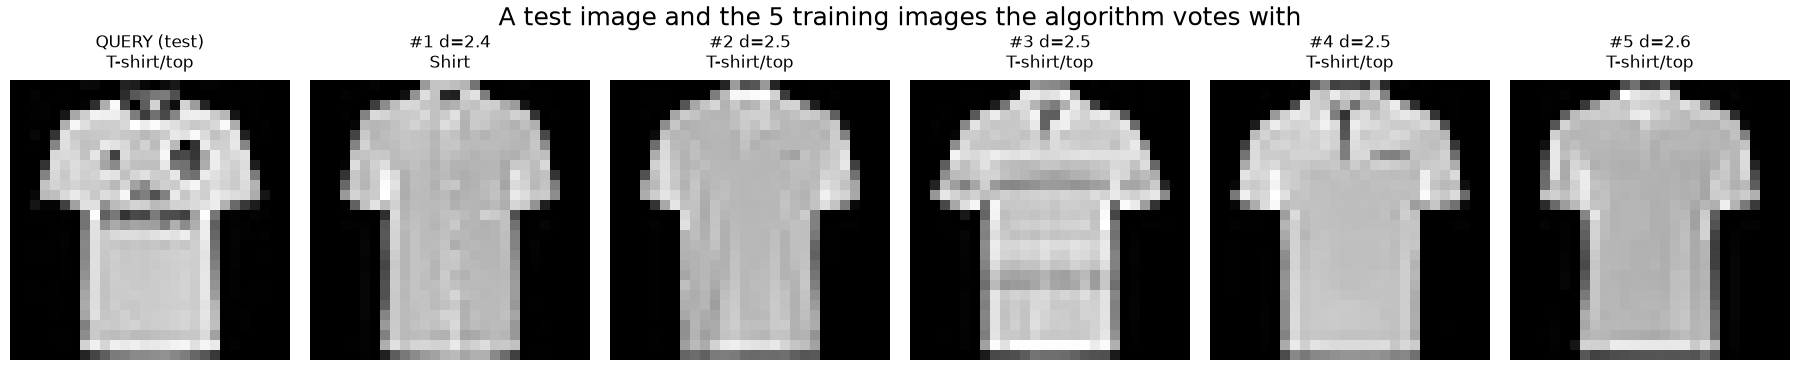

In [21]:
panel = np.vstack([X_test_raw[query : query + 1], X_train_raw[idxs[0]]])
titles = [f"QUERY (test)\n{CLASS_NAMES[y_test[query]]}"] + [
    f"#{r} d={d:.1f}\n{CLASS_NAMES[y_train[i]]}"
    for r, (d, i) in enumerate(zip(dists[0], idxs[0]), start=1)
]
path = plot_image_grid(
    panel, None, titles=titles, n_cols=6,
    filename="nearest_neighbours.png",
    suptitle="A test image and the 5 training images the algorithm votes with",
)
display(Image(filename=str(path)))

---
# Part 4 — Grid search with 5-fold cross-validation

We now search the cartesian product of every feature-engineering option and every
KNN hyperparameter, and score each permutation with  5-fold
cross-validation on the training set. The training rows are split into 5 equal,
class-balanced parts; each permutation is trained 5 times on 4 parts and validated on
the remaining one, and we report the mean validation macro-F1 across the 5 folds.


In [22]:
# --- Settings for this part --------------------------------------------------
CV_FOLDS = 5

# The cartesian product searched below. pca_components reuses the candidates
# already marked on the variance curve in part 2, so there is one source of truth.
PARAM_GRID = {
    "scaling": ["minmax", "standard"],
    "pca_components": PCA_CANDIDATES,
    "k": [1, 3, 5, 7],
    "metric": ["euclidean", "manhattan", "cosine"],
    "weights": ["uniform", "distance"],
}

# Training rows used inside the search. The whole cartesian product runs once per
# fold, so this is kept well below MAX_TRAIN_SAMPLES to keep the cost sane.
GRID_SEARCH_SAMPLES = 5000

In [23]:
grid = PARAM_GRID
n_perms = int(np.prod([len(v) for v in grid.values()]))

print("Search space:")
for name, values in grid.items():
    print(f"  {name:<15} {values}")
print(f"\n{n_perms} permutations x {CV_FOLDS} folds = {n_perms * CV_FOLDS} fits")

Search space:
  scaling         ['minmax', 'standard']
  pca_components  [30, 50, 100]
  k               [1, 3, 5, 7]
  metric          ['euclidean', 'manhattan', 'cosine']
  weights         ['uniform', 'distance']

144 permutations x 5 folds = 720 fits


The feature pipeline is refitted once
per (fold, scaling, PCA) combination rather than once per permutation, and the
distance matrix is computed once per metric and then reused for every k and every
weighting scheme by slicing the neighbours already found. The numbers are identical to
a naive nested loop; only the runtime differs.

In [24]:
def stratified_folds(y, n_folds=CV_FOLDS, seed=RANDOM_SEED):
    'Split indices into n_folds parts that each keep the class proportions.'
    rng = np.random.default_rng(seed)
    folds = [[] for _ in range(n_folds)]
    for cls in np.unique(y):
        idx = np.flatnonzero(y == cls)
        rng.shuffle(idx)
        # Dealing each class round-robin keeps every fold class-balanced.
        for fold_id, chunk in enumerate(np.array_split(idx, n_folds)):
            folds[fold_id].append(chunk)
    return [np.sort(np.concatenate(f)) for f in folds]


def _sorted_neighbours(X_train, X_val, metric, k_max, batch_size):
    'Distances and training indices of the k_max nearest neighbours, sorted.'
    distance_fn = METRICS[metric]
    dists = np.empty((X_val.shape[0], k_max), dtype=np.float64)
    idxs = np.empty((X_val.shape[0], k_max), dtype=np.int64)

    for start in range(0, X_val.shape[0], batch_size):
        batch = X_val[start : start + batch_size]
        dist = distance_fn(batch, X_train)
        part = np.argpartition(dist, k_max - 1, axis=1)[:, :k_max]
        d = np.take_along_axis(dist, part, axis=1)
        order = np.argsort(d, axis=1)
        stop = start + batch.shape[0]
        dists[start:stop] = np.take_along_axis(d, order, axis=1)
        idxs[start:stop] = np.take_along_axis(part, order, axis=1)

    return dists, idxs

In [25]:
def run_grid_search(X, y, param_grid=None, n_folds=CV_FOLDS, seed=RANDOM_SEED, verbose=True):
    'Score every permutation with k-fold CV and return one row per permutation.'
    grid = param_grid or PARAM_GRID
    folds = stratified_folds(y, n_folds, seed)
    classes = np.unique(y)

    feature_combos = list(itertools.product(grid["scaling"], grid["pca_components"]))
    k_values = sorted(grid["k"])
    k_max = max(k_values)
    # fold_scores[permutation key] -> list of per-fold macro-F1 values.
    fold_scores = {}

    for fold_id in range(n_folds):
        val_idx = folds[fold_id]
        train_idx = np.concatenate([folds[i] for i in range(n_folds) if i != fold_id])
        X_tr_raw, y_tr = X[train_idx], y[train_idx]
        X_val_raw, y_val = X[val_idx], y[val_idx]

        for scaling, pca_components in feature_combos:
            # Fitted on this fold's training part only - the validation part is
            # unseen, exactly as the test set will be later.
            pipeline = FeaturePipeline(scaling, pca_components, seed).fit(X_tr_raw)
            X_tr = pipeline.transform(X_tr_raw)
            X_val = pipeline.transform(X_val_raw)

            for metric in grid["metric"]:
                started = time.perf_counter()
                dists, idxs = _sorted_neighbours(
                    X_tr, X_val, metric, k_max, PREDICT_BATCH_SIZE)
                neighbour_labels = y_tr[idxs]

                # One set of neighbours serves every k and both weightings.
                for k in k_values:
                    for weights in grid["weights"]:
                        proba = vote(
                            neighbour_labels[:, :k], dists[:, :k], classes, weights)
                        score = macro_f1(y_val, classes[np.argmax(proba, axis=1)])
                        key = (scaling, pca_components, k, metric, weights)
                        fold_scores.setdefault(key, []).append(score)

                if verbose:
                    print(f"fold {fold_id + 1}/{n_folds} | scaling={scaling} "
                          f"pca={pca_components} metric={metric} "
                          f"({time.perf_counter() - started:.1f}s)")

    rows = [
        {
            "scaling": scaling,
            "pca_components": pca_components,
            "k": k,
            "metric": metric,
            "weights": weights,
            "mean_macro_f1": float(np.mean(scores)),
            "std_macro_f1": float(np.std(scores)),
            **{f"fold{i + 1}_macro_f1": s for i, s in enumerate(scores)},
        }
        for (scaling, pca_components, k, metric, weights), scores in fold_scores.items()
    ]

    return (pd.DataFrame(rows)
            .sort_values("mean_macro_f1", ascending=False)
            .reset_index(drop=True))


def best_params(results):
    'Extract the winning permutation from a grid-search results table.'
    row = results.iloc[0]
    return {
        "scaling": row["scaling"],
        "pca_components": int(row["pca_components"]),
        "k": int(row["k"]),
        "metric": row["metric"],
        "weights": row["weights"],
        "mean_macro_f1": float(row["mean_macro_f1"]),
    }

In [26]:
# Grid search runs on GRID_SEARCH_SAMPLES rows so the search stays tractable.
X_grid, y_grid = stratified_subsample(
    X_train_raw_full, y_train_full, GRID_SEARCH_SAMPLES)
print(f"grid search training rows: {len(y_grid):,}")

started = time.perf_counter()
results = run_grid_search(X_grid, y_grid, verbose=False)
print(f"grid search finished in {time.perf_counter() - started:.1f}s")

results.to_csv(OUTPUT_DIR / "grid_search_results.csv", index=False)
print(f"{len(results)} permutations scored")

grid search training rows: 5,000


grid search finished in 49.9s
144 permutations scored


### All permutations and their mean cross-validated macro-F1

In [27]:
display_cols = ["scaling", "pca_components", "k", "metric", "weights",
                "mean_macro_f1", "std_macro_f1"]
pd.set_option("display.max_rows", 250)
results[display_cols]

,scaling,pca_components,k,metric,weights,mean_macro_f1,std_macro_f1
0,minmax,100,7,cosine,distance,0.826077,0.007089
1,minmax,100,5,cosine,distance,0.825613,0.007907
2,standard,50,7,manhattan,distance,0.824482,0.010114
3,standard,100,3,manhattan,distance,0.823771,0.008915
4,standard,100,7,cosine,distance,0.823542,0.007413
5,minmax,50,5,cosine,distance,0.823474,0.011295
6,standard,100,5,manhattan,distance,0.823209,0.011253
7,minmax,100,5,manhattan,distance,0.823177,0.008588
8,minmax,100,7,manhattan,distance,0.822110,0.008011
9,standard,50,3,manhattan,distance,0.822021,0.010060


### The best permutation

In [28]:
best = best_params(results)

print("BEST PERMUTATION")
print("-" * 46)
for key in ["scaling", "pca_components", "k", "metric", "weights"]:
    print(f"  {key:<16}: {best[key]}")
print("-" * 46)
print(f"  mean CV macro-F1: {best['mean_macro_f1']:.4f}")
print(f"  std  across folds: {results.iloc[0]['std_macro_f1']:.4f}")
print("\nper-fold scores:")
fold_cols = [c for c in results.columns if c.startswith("fold")]
print(results.iloc[0][fold_cols].to_string())

BEST PERMUTATION
----------------------------------------------
  scaling         : minmax
  pca_components  : 100
  k               : 7
  metric          : cosine
  weights         : distance
----------------------------------------------
  mean CV macro-F1: 0.8261
  std  across folds: 0.0071

per-fold scores:
fold1_macro_f1    0.820628
fold2_macro_f1    0.831602
fold3_macro_f1    0.834149
fold4_macro_f1     0.82881
fold5_macro_f1    0.815196


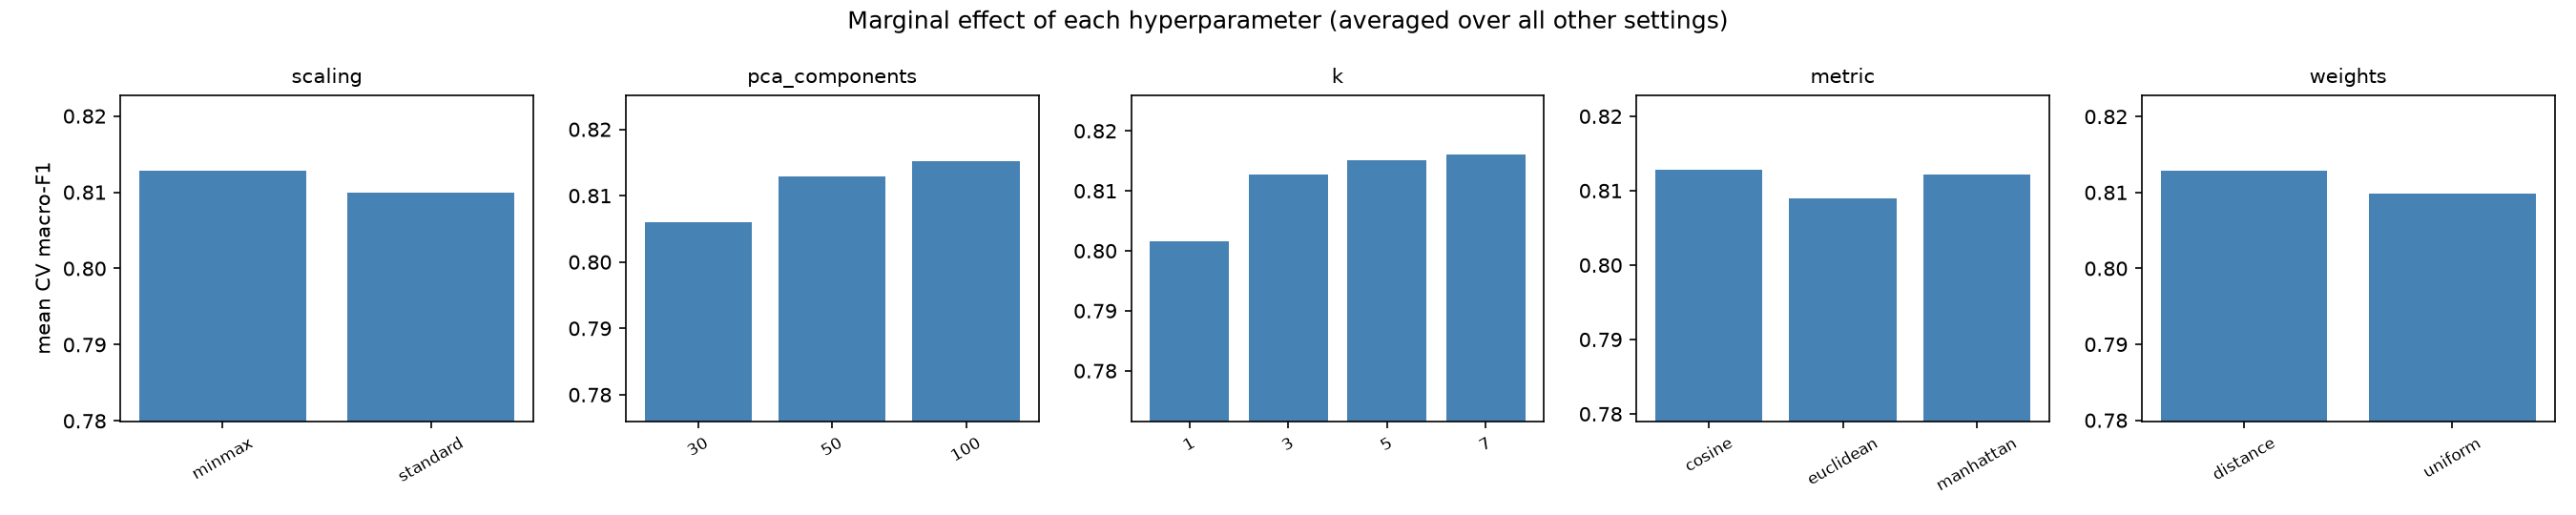

In [29]:
# How each hyperparameter behaves on its own, averaged over everything else.
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6))
for ax, param in zip(axes, ["scaling", "pca_components", "k", "metric", "weights"]):
    means = results.groupby(param)["mean_macro_f1"].mean()
    ax.bar([str(v) for v in means.index], means.values, color="steelblue")
    ax.set_title(param, fontsize=10)
    ax.set_ylim(means.min() - 0.03, means.max() + 0.01)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
axes[0].set_ylabel("mean CV macro-F1")
fig.suptitle("Marginal effect of each hyperparameter (averaged over all other settings)")
fig.tight_layout()
p = FIGURES_DIR / "hyperparameter_effects.png"
fig.savefig(p, dpi=150)
plt.close(fig)
display(Image(filename=str(p)))

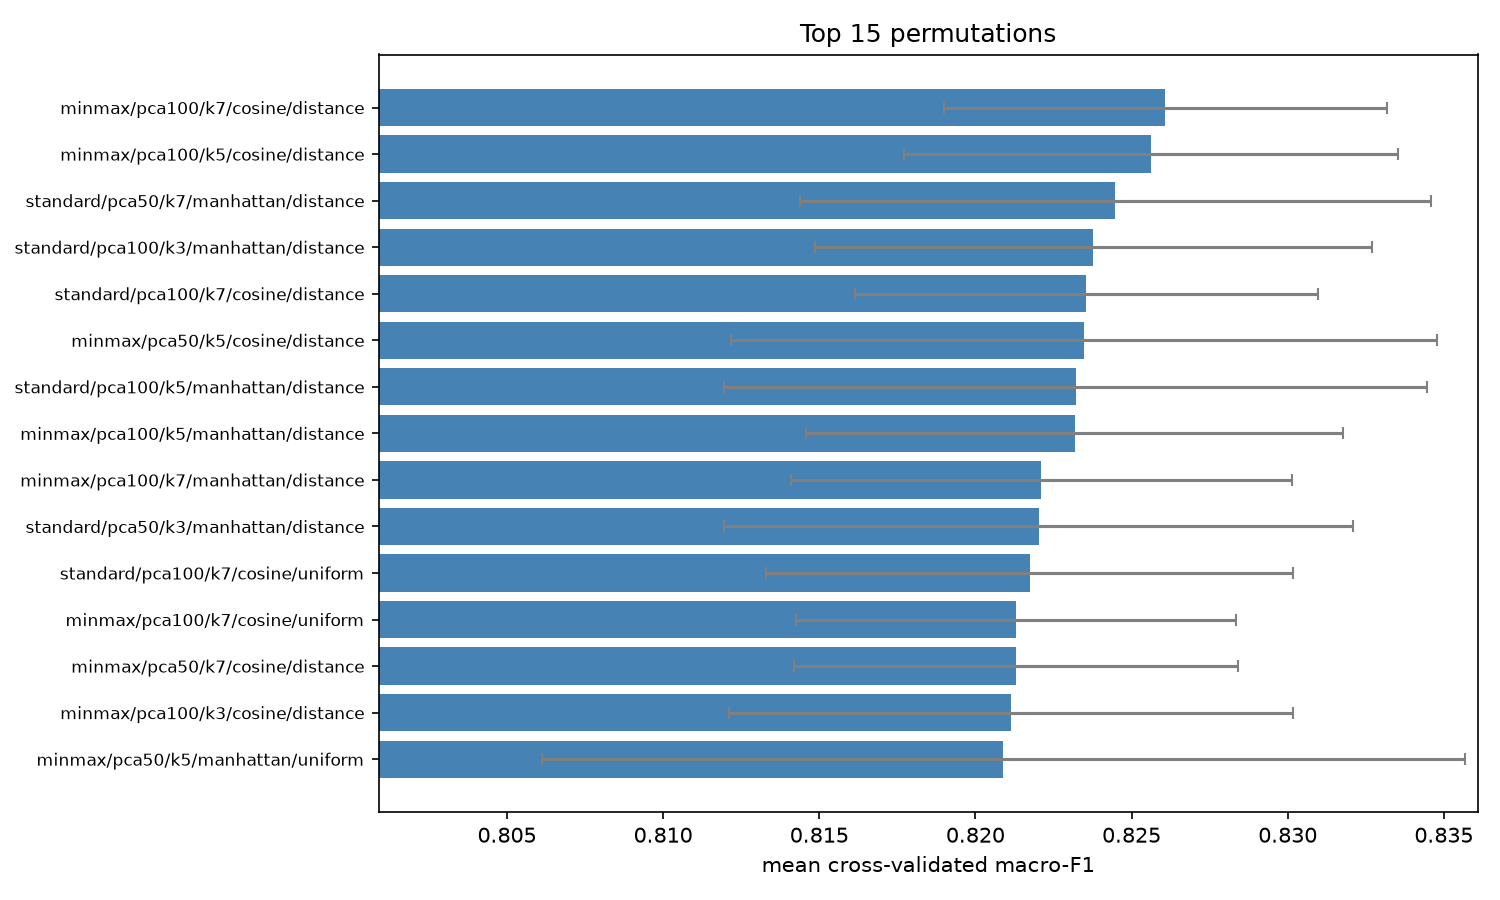

In [30]:
top = results.head(15).iloc[::-1]
labels = [f"{r.scaling}/pca{r.pca_components}/k{r.k}/{r.metric}/{r.weights}"
          for r in top.itertuples()]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels, top["mean_macro_f1"], xerr=top["std_macro_f1"],
        color="steelblue", ecolor="grey", capsize=3)
ax.set_xlim(top["mean_macro_f1"].min() - 0.02, top["mean_macro_f1"].max() + 0.01)
ax.set_xlabel("mean cross-validated macro-F1")
ax.set_title("Top 15 permutations")
ax.tick_params(axis="y", labelsize=8)
fig.tight_layout()
p = FIGURES_DIR / "top_permutations.png"
fig.savefig(p, dpi=150)
plt.close(fig)
display(Image(filename=str(p)))

---
# Part 5 — Training the final model on the whole training set

With the winning permutation chosen by cross-validation, we now refit on the entire working training set: the feature pipeline is re-fitted on
all training rows, and the classifier stores all of them.

In [31]:
final_pipeline = FeaturePipeline(
    scaling=best["scaling"],
    pca_components=best["pca_components"],
).fit(X_train_raw)

Z_train = final_pipeline.transform(X_train_raw)

final_model = KNNClassifier(
    k=best["k"], metric=best["metric"], weights=best["weights"]
).fit(Z_train, y_train)

print("feature pipeline :", final_pipeline.describe())
print(f"variance retained: {final_pipeline.explained_variance:.2%}")
print("model            :", final_model)
print(f"training matrix  : {Z_train.shape[0]:,} rows x {Z_train.shape[1]} features")

feature pipeline : scaling=minmax, PCA(100)
variance retained: 91.22%
model            : KNNClassifier(k=7, metric='cosine', weights='distance')
training matrix  : 60,000 rows x 100 features


### training examples through the final feature engineering

In [32]:
show = [0, 1, 2]
stage_scaled = final_pipeline.scaler.transform(X_train_raw[show])
stage_pca = final_pipeline.transform(X_train_raw[show])

for i, row in enumerate(show):
    print(f"TRAIN row {row} - {CLASS_NAMES[y_train[row]]}")
    print(f"  raw    (784 dims): {np.array2string(X_train_raw[row][:8], precision=0)} ... "
          f"range [{X_train_raw[row].min():.0f}, {X_train_raw[row].max():.0f}]")
    print(f"  scaled (784 dims): {np.array2string(stage_scaled[i][:8], precision=3)} ... "
          f"range [{stage_scaled[i].min():.2f}, {stage_scaled[i].max():.2f}]")
    print(f"  PCA    ({stage_pca.shape[1]:>3} dims): "
          f"{np.array2string(stage_pca[i][:8], precision=3)} ...")
    print()

TRAIN row 0 - Pullover
  raw    (784 dims): [0. 0. 0. 0. 0. 0. 0. 0.] ... range [0, 255]
  scaled (784 dims): [0. 0. 0. 0. 0. 0. 0. 0.] ... range [0.00, 1.00]
  PCA    (100 dims): [ 3.686  4.961 -0.051 -2.734  0.392  1.149  0.875 -2.567] ...

TRAIN row 1 - Ankle boot
  raw    (784 dims): [0. 0. 0. 0. 0. 0. 0. 0.] ... range [0, 255]
  scaled (784 dims): [0. 0. 0. 0. 0. 0. 0. 0.] ... range [0.00, 1.00]
  PCA    (100 dims): [-4.377  3.86  -1.948 -0.803  0.451 -0.78  -1.231 -1.014] ...

TRAIN row 2 - Shirt
  raw    (784 dims): [0. 0. 0. 0. 0. 0. 0. 5.] ... range [0, 255]
  scaled (784 dims): [0.   0.   0.   0.   0.   0.   0.   0.02] ... range [0.00, 1.00]
  PCA    (100 dims): [ 7.265  1.569  2.315  0.222  1.048 -1.162 -1.071  0.302] ...



---
# Part 6 — Prediction and evaluation on the test set


The test file is opened here for the first time as a scoring set. Its rows are pushed
through the already-fitted training pipeline — no statistic is re-estimated on
them.

In [33]:
show_test = [0, 1, 2]
te_scaled = final_pipeline.scaler.transform(X_test_raw[show_test])
te_pca = final_pipeline.transform(X_test_raw[show_test])

for i, row in enumerate(show_test):
    print(f"TEST row {row} - {CLASS_NAMES[y_test[row]]}")
    print(f"  raw    (784 dims): {np.array2string(X_test_raw[row][:8], precision=0)} ... "
          f"range [{X_test_raw[row].min():.0f}, {X_test_raw[row].max():.0f}]")
    print(f"  scaled (784 dims): {np.array2string(te_scaled[i][:8], precision=3)} ... "
          f"range [{te_scaled[i].min():.2f}, {te_scaled[i].max():.2f}]")
    print(f"  PCA    ({te_pca.shape[1]:>3} dims): "
          f"{np.array2string(te_pca[i][:8], precision=3)} ...")
    print()

TEST row 0 - T-shirt/top
  raw    (784 dims): [0. 0. 0. 0. 0. 0. 0. 9.] ... range [0, 255]
  scaled (784 dims): [0.    0.    0.    0.    0.    0.    0.    0.035] ... range [0.00, 1.00]
  PCA    (100 dims): [ 5.474 -1.444 -0.676  0.796  1.135  4.019 -0.554 -0.701] ...

TEST row 1 - Trouser
  raw    (784 dims): [0. 0. 0. 0. 0. 0. 0. 0.] ... range [0, 255]
  scaled (784 dims): [0. 0. 0. 0. 0. 0. 0. 0.] ... range [0.00, 1.00]
  PCA    (100 dims): [-0.227 -6.094 -1.299 -0.895 -1.648 -1.877  1.596 -0.785] ...

TEST row 2 - Pullover
  raw    (784 dims): [ 0.  0.  0.  0.  0.  0. 14. 53.] ... range [0, 254]
  scaled (784 dims): [0.    0.    0.    0.    0.    0.    0.062 0.208] ... range [0.00, 1.00]
  PCA    (100 dims): [-3.215 -0.573  3.289  1.483 -2.324  0.209 -0.44  -0.201] ...



In [34]:
Z_test = final_pipeline.transform(X_test_raw)

started = time.perf_counter()
y_pred = final_model.predict(Z_test)
print(f"predicted {len(y_pred):,} test images in {time.perf_counter() - started:.1f}s")

predicted 10,000 test images in 6.5s


### The first 5 test predictions

In [35]:
proba_head = final_model.predict_proba(Z_test[:5])
first5 = pd.DataFrame({
    "test row": range(5),
    "true label": y_test[:5],
    "true class": [CLASS_NAMES[c] for c in y_test[:5]],
    "predicted label": y_pred[:5],
    "predicted class": [CLASS_NAMES[c] for c in y_pred[:5]],
    "vote share": [f"{proba_head[i, y_pred[i]]:.2f}" for i in range(5)],
    "correct": y_test[:5] == y_pred[:5],
})
first5

,test row,true label,true class,predicted label,predicted class,vote share,correct
0,0,0,T-shirt/top,0,T-shirt/top,0.87,True
1,1,1,Trouser,1,Trouser,1.00,True
2,2,2,Pullover,2,Pullover,0.65,True
3,3,2,Pullover,2,Pullover,0.86,True
4,4,3,Dress,3,Dress,0.86,True


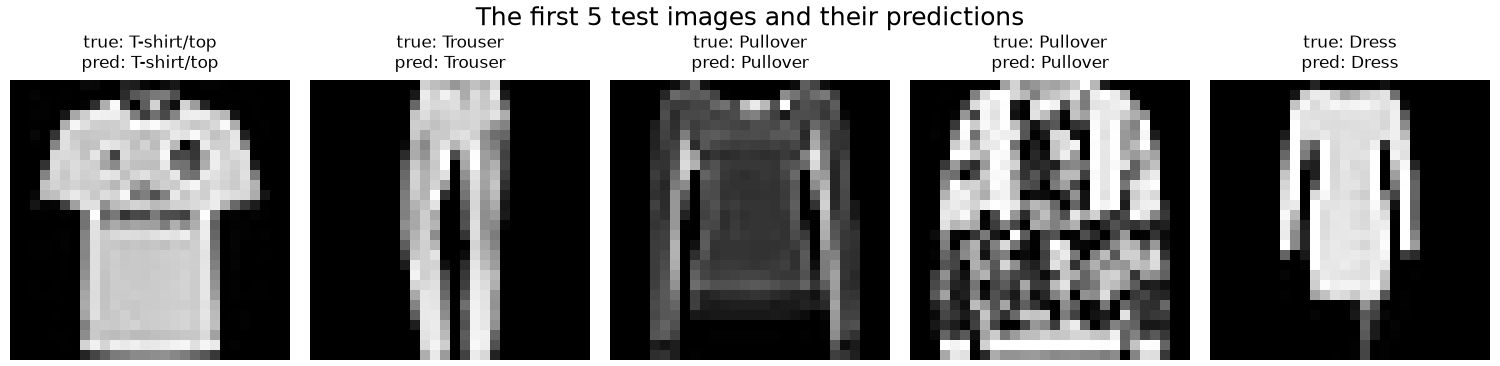

In [36]:
path = plot_image_grid(
    X_test_raw[:5], y_test[:5],
    titles=[f"true: {CLASS_NAMES[y_test[i]]}\npred: {CLASS_NAMES[y_pred[i]]}"
            for i in range(5)],
    n_cols=5,
    filename="first5_predictions.png",
    suptitle="The first 5 test images and their predictions",
)
display(Image(filename=str(path)))

### Model quality — macro-average F1

In [37]:
scores = summary_scores(y_test, y_pred)

print("=" * 50)
print(f"  MACRO-AVERAGE F1 : {scores['macro_f1']:.4f}   <-- headline metric")
print("=" * 50)
print(f"  weighted F1      : {scores['weighted_f1']:.4f}")
print(f"  accuracy         : {scores['accuracy']:.4f}")
print()
print(f"  CV estimate was  : {best['mean_macro_f1']:.4f}")
print(f"  gap (test - CV)  : {scores['macro_f1'] - best['mean_macro_f1']:+.4f}")

  MACRO-AVERAGE F1 : 0.8721   <-- headline metric
  weighted F1      : 0.8721
  accuracy         : 0.8732

  CV estimate was  : 0.8261
  gap (test - CV)  : +0.0461


In [38]:
report = per_class_report(y_test, y_pred)
report.sort_values("f1", ascending=False)

,class_name,precision,recall,f1,support
1,Trouser,0.987792,0.971,0.979324,1000
8,Bag,0.967066,0.969,0.968032,1000
9,Ankle boot,0.903104,0.960,0.930683,1000
5,Sandal,0.974586,0.882,0.925984,1000
7,Sneaker,0.896453,0.935,0.915321,1000
3,Dress,0.913088,0.893,0.902932,1000
0,T-shirt/top,0.776199,0.874,0.822201,1000
4,Coat,0.788301,0.849,0.817525,1000
2,Pullover,0.810700,0.788,0.799189,1000
6,Shirt,0.717979,0.611,0.660184,1000


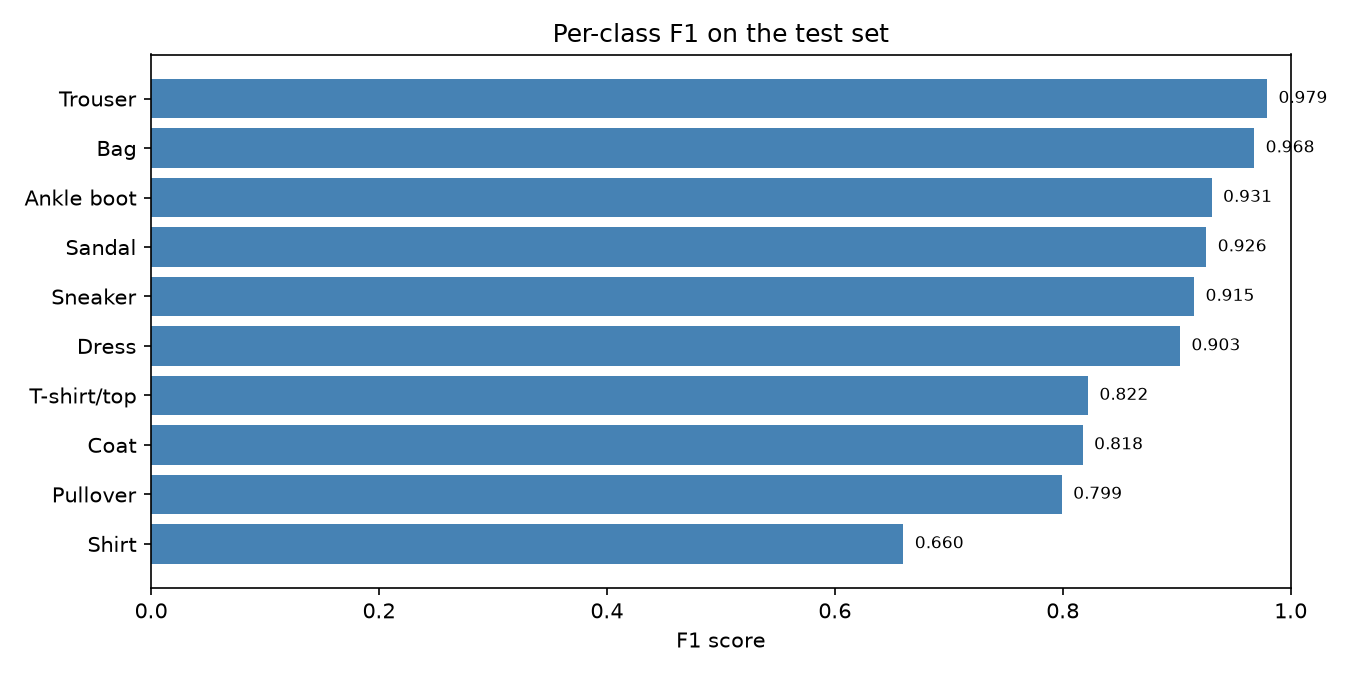

In [39]:
display(Image(filename=str(plot_per_class_f1(report))))

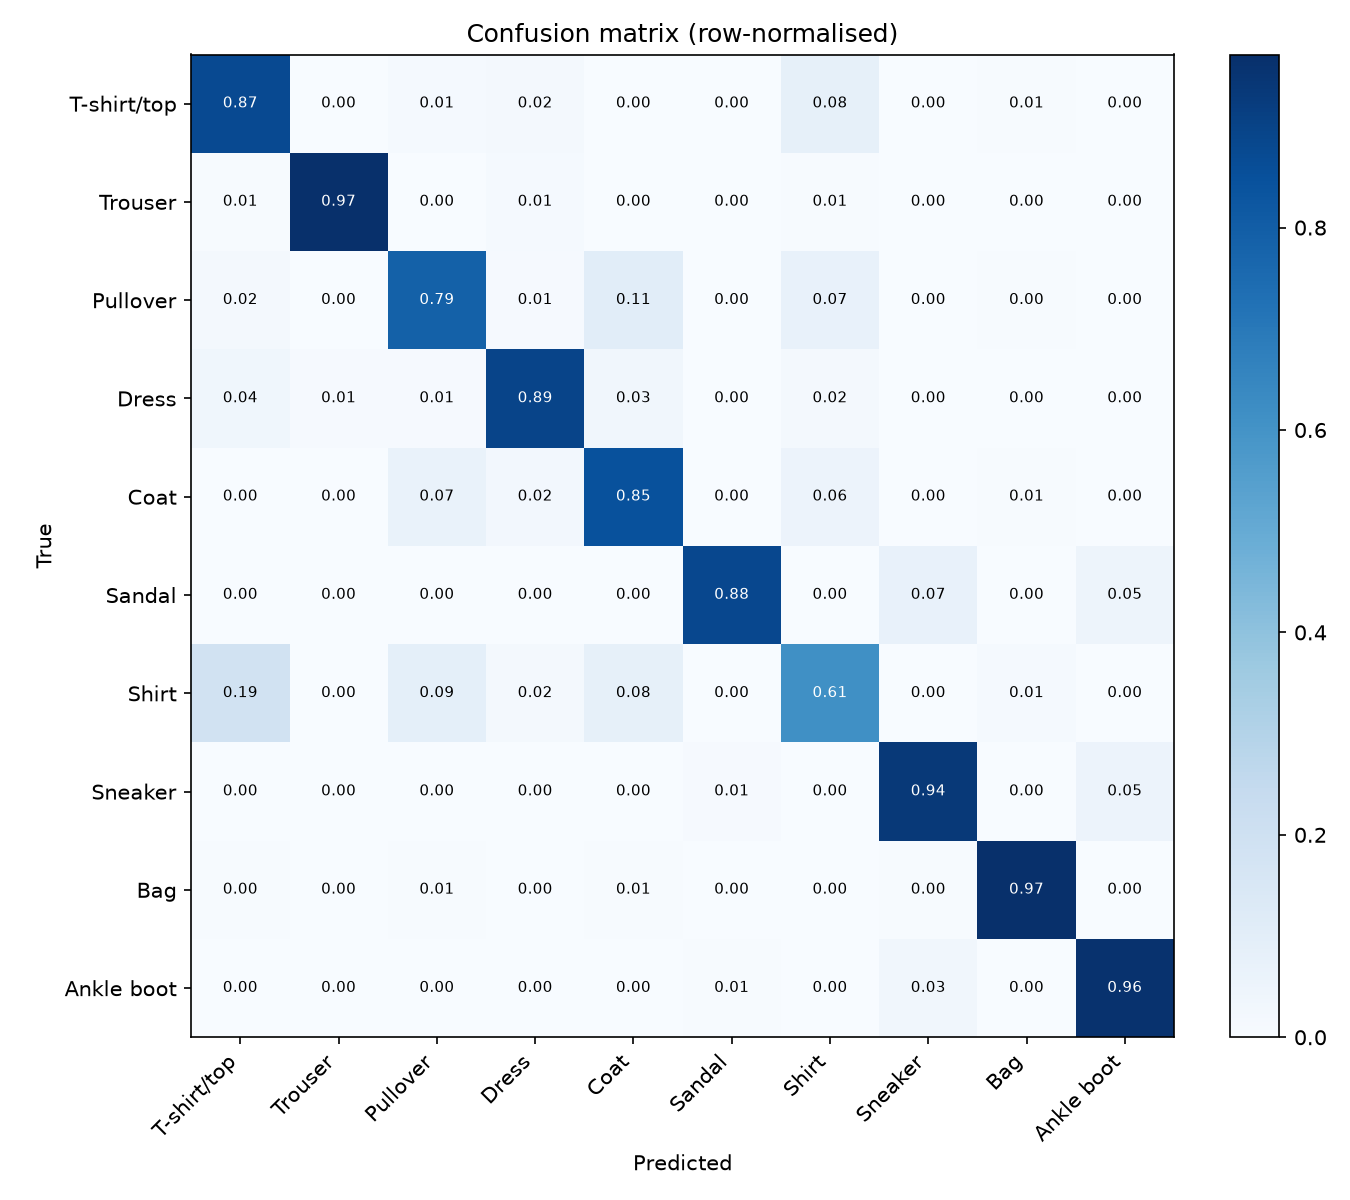

In [40]:
display(Image(filename=str(plot_confusion_matrix(y_test, y_pred))))

### Where the model fails

In [41]:
wrong = np.flatnonzero(y_pred != y_test)
print(f"{len(wrong):,} of {len(y_test):,} test images misclassified "
      f"({len(wrong) / len(y_test):.1%})")

pairs = pd.Series(
    [f"{CLASS_NAMES[y_test[i]]} -> {CLASS_NAMES[y_pred[i]]}" for i in wrong]
).value_counts().head(10)
pd.DataFrame({"true -> predicted": pairs.index, "count": pairs.values})

1,268 of 10,000 test images misclassified (12.7%)


,true -> predicted,count
0,Shirt -> T-shirt/top,189
1,Pullover -> Coat,106
2,Shirt -> Pullover,88
3,T-shirt/top -> Shirt,83
4,Shirt -> Coat,80
5,Pullover -> Shirt,74
6,Sandal -> Sneaker,69
7,Coat -> Pullover,65
8,Coat -> Shirt,56
9,Sneaker -> Ankle boot,54


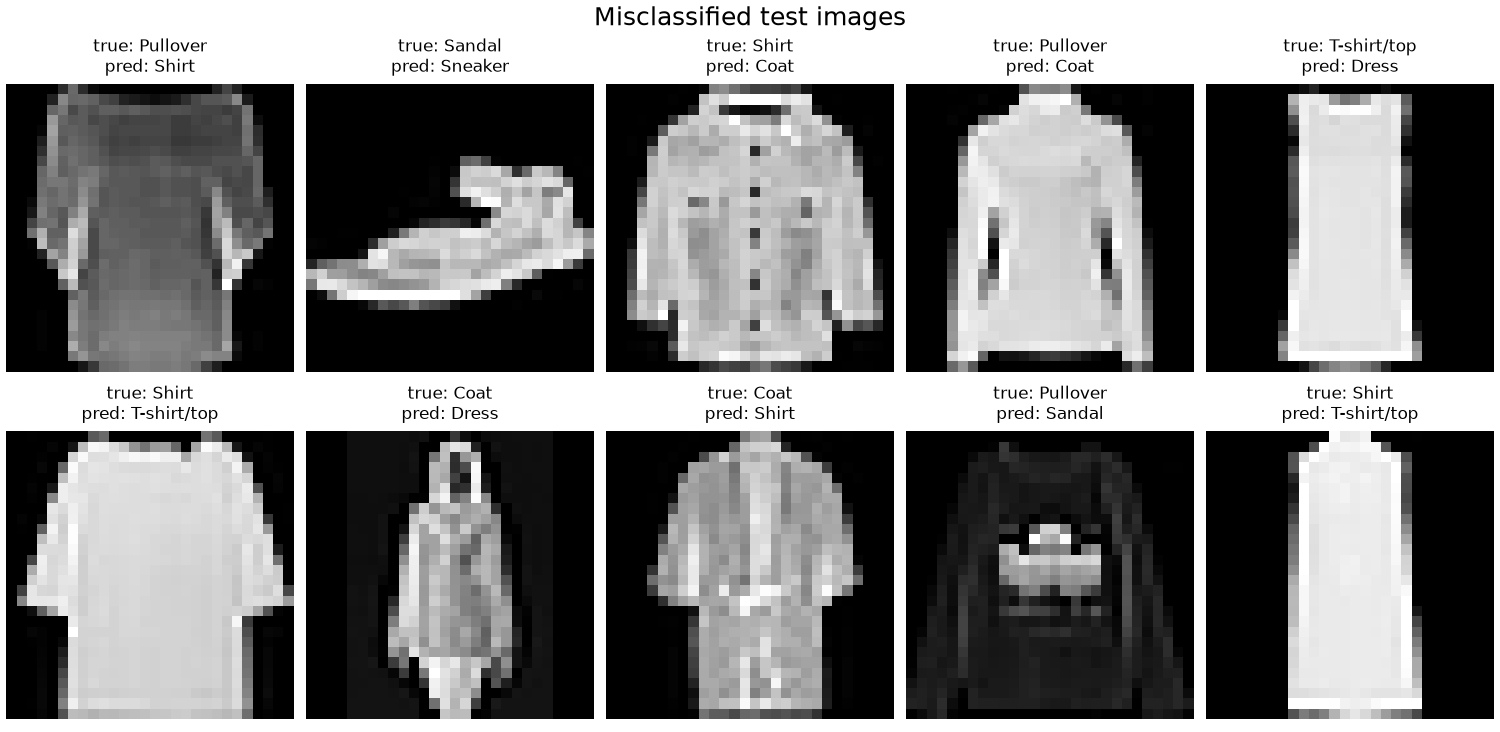

In [42]:
sample_wrong = wrong[:10]
path = plot_image_grid(
    X_test_raw[sample_wrong], None,
    titles=[f"true: {CLASS_NAMES[y_test[i]]}\npred: {CLASS_NAMES[y_pred[i]]}"
            for i in sample_wrong],
    n_cols=5,
    filename="misclassified.png",
    suptitle="Misclassified test images",
)
display(Image(filename=str(path)))

---
# Part 7 — Explainability: why the model made each prediction

*Answers assignment part 6c (bonus extension).*

KNN has an unusual advantage here. Most classifiers compress their training data
into weights, and recovering "which examples caused this prediction" needs an
approximation method such as SHAP. A KNN prediction is a list of training examples
and their distances — the evidence is the model's own output, exact rather than
estimated. We use that first, then add three techniques that do not depend on it.

1. **Case-based explanation** — the exact training images that voted, and their weight.
2. **Vote margin as a confidence signal** — does the model know when it is unsure?
3. **Occlusion sensitivity** — which pixels the decision actually depended on.


### 1. Case-based explanation: the evidence behind one prediction

For any test image we can list the exact training images that voted, how far away
each one was, and how much of the final decision it owned. With `weights="distance"`
each neighbour's influence is proportional to $1/d$

We look at two cases: one the model got right with near-total agreement, and the one
it got **most confidently wrong**. The second is the more informative of the two.

In [43]:
proba_test = final_model.predict_proba(Z_test)

# Margin between the winning class and the runner-up = how decisive the vote was.
sorted_proba = np.sort(proba_test, axis=1)
margin = sorted_proba[:, -1] - sorted_proba[:, -2]
correct_mask = y_pred == y_test

confident_correct = int(np.flatnonzero(correct_mask)[np.argmax(margin[correct_mask])])
confident_wrong = int(np.flatnonzero(~correct_mask)[np.argmax(margin[~correct_mask])])


def explain_prediction(row_id):
    'List the training images that voted for one test prediction, with their weight.'
    dists, idxs = final_model.kneighbors(Z_test[row_id : row_id + 1])
    d, i = dists[0], idxs[0]
    # This is exactly the weighting the classifier used internally.
    w = 1.0 / np.maximum(d, 1e-12)
    return pd.DataFrame({
        "rank": np.arange(1, len(i) + 1),
        "train row": i,
        "neighbour class": [CLASS_NAMES[c] for c in y_train[i]],
        "distance": np.round(d, 4),
        "weight (1/d)": np.round(w, 2),
        "share of vote": np.round(w / w.sum(), 3),
    })


for label, row_id in [("CONFIDENT AND CORRECT", confident_correct),
                      ("CONFIDENT BUT WRONG", confident_wrong)]:
    print("=" * 62)
    print(f"{label}  -  test row {row_id}")
    print(f"  true      : {CLASS_NAMES[y_test[row_id]]}")
    print(f"  predicted : {CLASS_NAMES[y_pred[row_id]]}")
    print(f"  margin    : {margin[row_id]:.3f}")
    print()
    print(explain_prediction(row_id).to_string(index=False))
    print()

CONFIDENT AND CORRECT  -  test row 1
  true      : Trouser
  predicted : Trouser
  margin    : 1.000

 rank  train row neighbour class  distance  weight (1/d)  share of vote
    1      17401         Trouser    0.0244         41.07          0.167
    2       1788         Trouser    0.0275         36.36          0.148
    3      38069         Trouser    0.0280         35.66          0.145
    4      36592         Trouser    0.0297         33.71          0.137
    5      17006         Trouser    0.0301         33.18          0.135
    6       5851         Trouser    0.0305         32.80          0.134
    7      49401         Trouser    0.0308         32.46          0.132

CONFIDENT BUT WRONG  -  test row 51
  true      : Pullover
  predicted : Coat
  margin    : 1.000

 rank  train row neighbour class  distance  weight (1/d)  share of vote
    1      38469            Coat    0.0340         29.38          0.187
    2      23122            Coat    0.0375         26.66          0.170
    3 

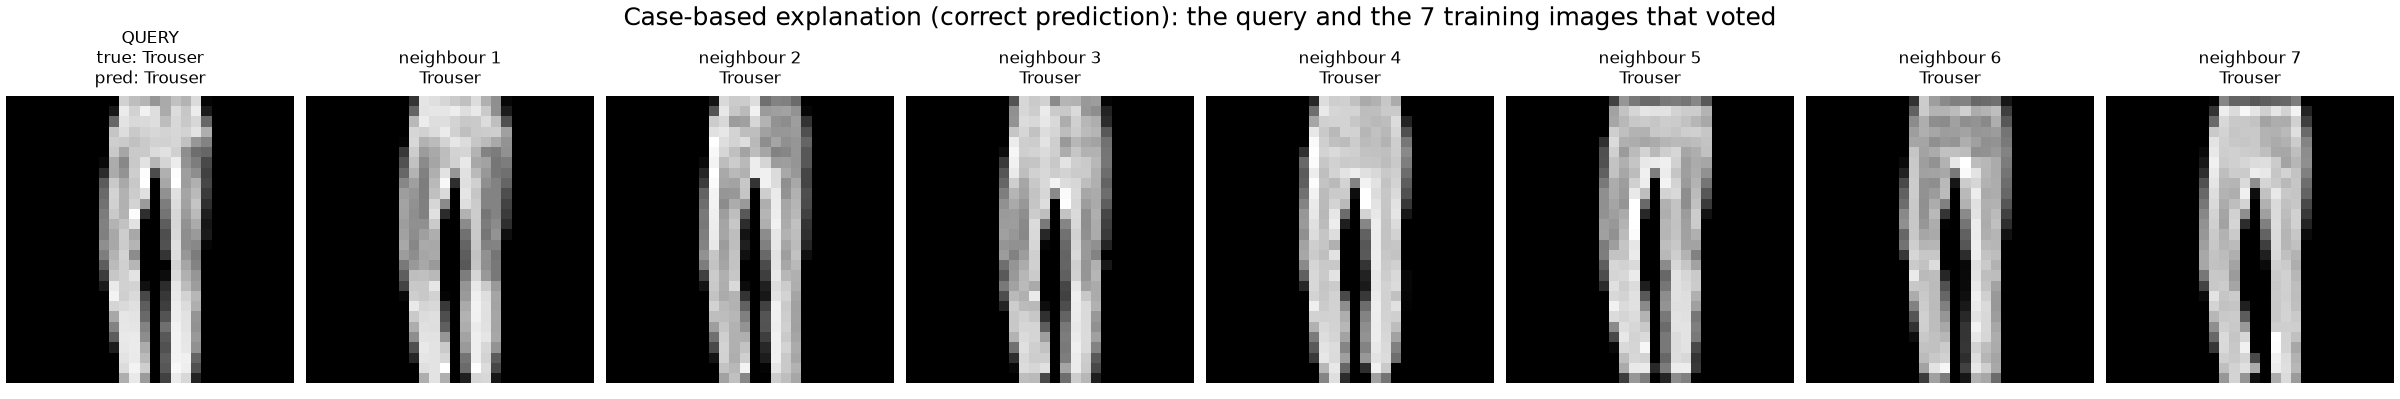

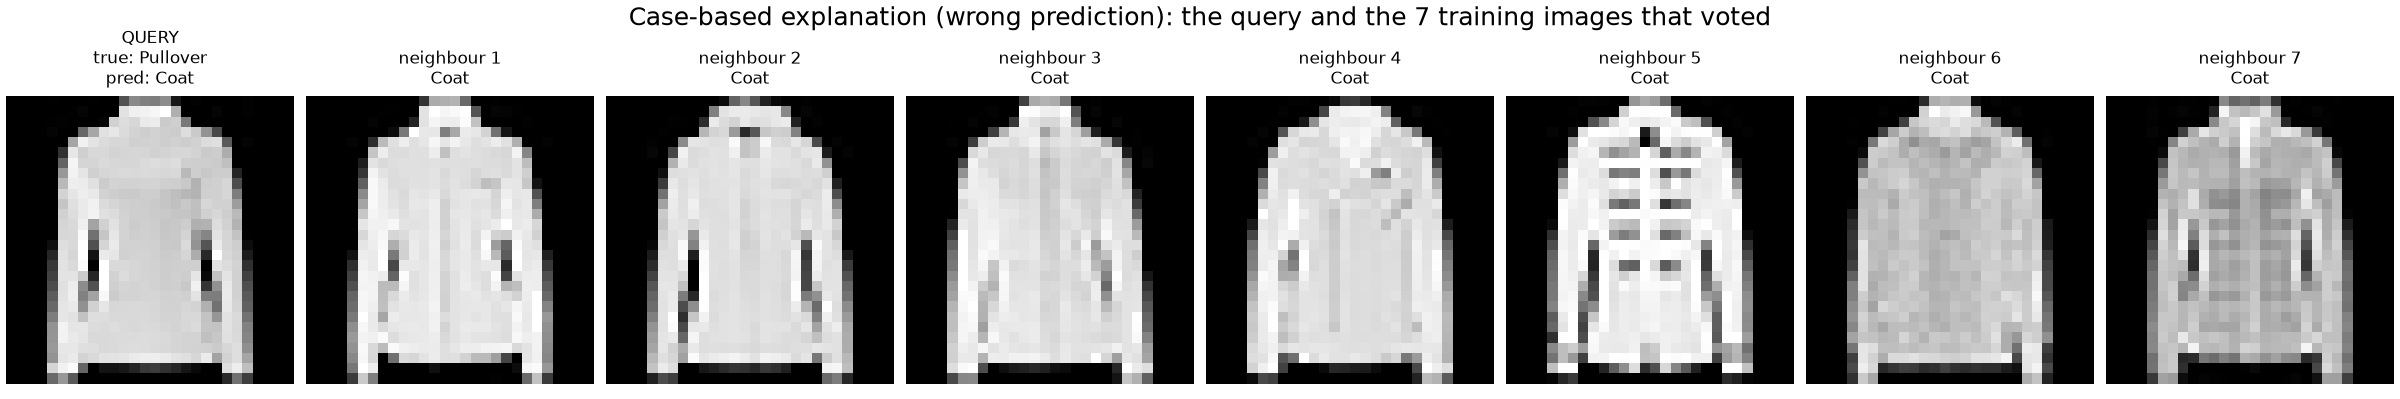

In [44]:
# The query image beside the seven training images that decided its label.
for label, row_id in [("correct", confident_correct), ("wrong", confident_wrong)]:
    _, idxs = final_model.kneighbors(Z_test[row_id : row_id + 1])
    panel = np.vstack([X_test_raw[row_id : row_id + 1], X_train_raw[idxs[0]]])
    titles = [f"QUERY\ntrue: {CLASS_NAMES[y_test[row_id]]}\npred: {CLASS_NAMES[y_pred[row_id]]}"]
    titles += [f"neighbour {r}\n{CLASS_NAMES[y_train[i]]}"
               for r, i in enumerate(idxs[0], start=1)]
    path = plot_image_grid(
        panel, None, titles=titles, n_cols=8,
        filename=f"explain_neighbours_{label}.png",
        suptitle=f"Case-based explanation ({label} prediction): "
                 f"the query and the {best['k']} training images that voted",
    )
    display(Image(filename=str(path)))

The wrong case is the interesting one. The neighbours it retrieved are not random
mistakes — they are genuinely similar garments from a neighbouring category. The
model failed on an image that is hard rather than on one it handled carelessly, and
the explanation lets us verify that directly instead of guessing.

### 2. Is the model's confidence meaningful?

The **vote margin** — the winning class's share minus the runner-up's — is available
with every prediction at no extra cost. If it carries real information, accuracy
should rise steeply with it. That would make it usable as an abstention signal: a
deployed system could route low-margin images to a human.

We ask for five equal-sized bands, but far fewer come back. With `k=7` a large share
of predictions are **unanimous** — all seven neighbours agree, so the margin is
exactly 1.0 — and several quantile edges land on that same value and merge. The
merging is itself a finding worth stating: most predictions are not close calls.

In [45]:
# Group the test predictions into five equal-sized margin bands. Margins are
# discrete when k is small, so duplicates="drop" merges bands that would share an
# edge rather than leaving an empty one behind.
bands = pd.qcut(margin, 5, duplicates="drop")
total_errors = max(int((~correct_mask).sum()), 1)

rows = []
for interval in bands.categories:
    sel = np.flatnonzero(bands == interval)
    if sel.size == 0:
        continue
    rows.append({
        "margin band": f"{max(interval.left, 0.0):.2f} - {interval.right:.2f}",
        "images": sel.size,
        "accuracy": float(correct_mask[sel].mean()),
        "macro-F1": macro_f1(y_test[sel], y_pred[sel]),
        "share of all errors": float((~correct_mask[sel]).sum() / total_errors),
    })
margin_table = pd.DataFrame(rows)
margin_table

,margin band,images,accuracy,macro-F1,share of all errors
0,0.00 - 0.50,2000,0.566,0.555342,0.684543
1,0.50 - 1.00,8000,0.950,0.940590,0.315457


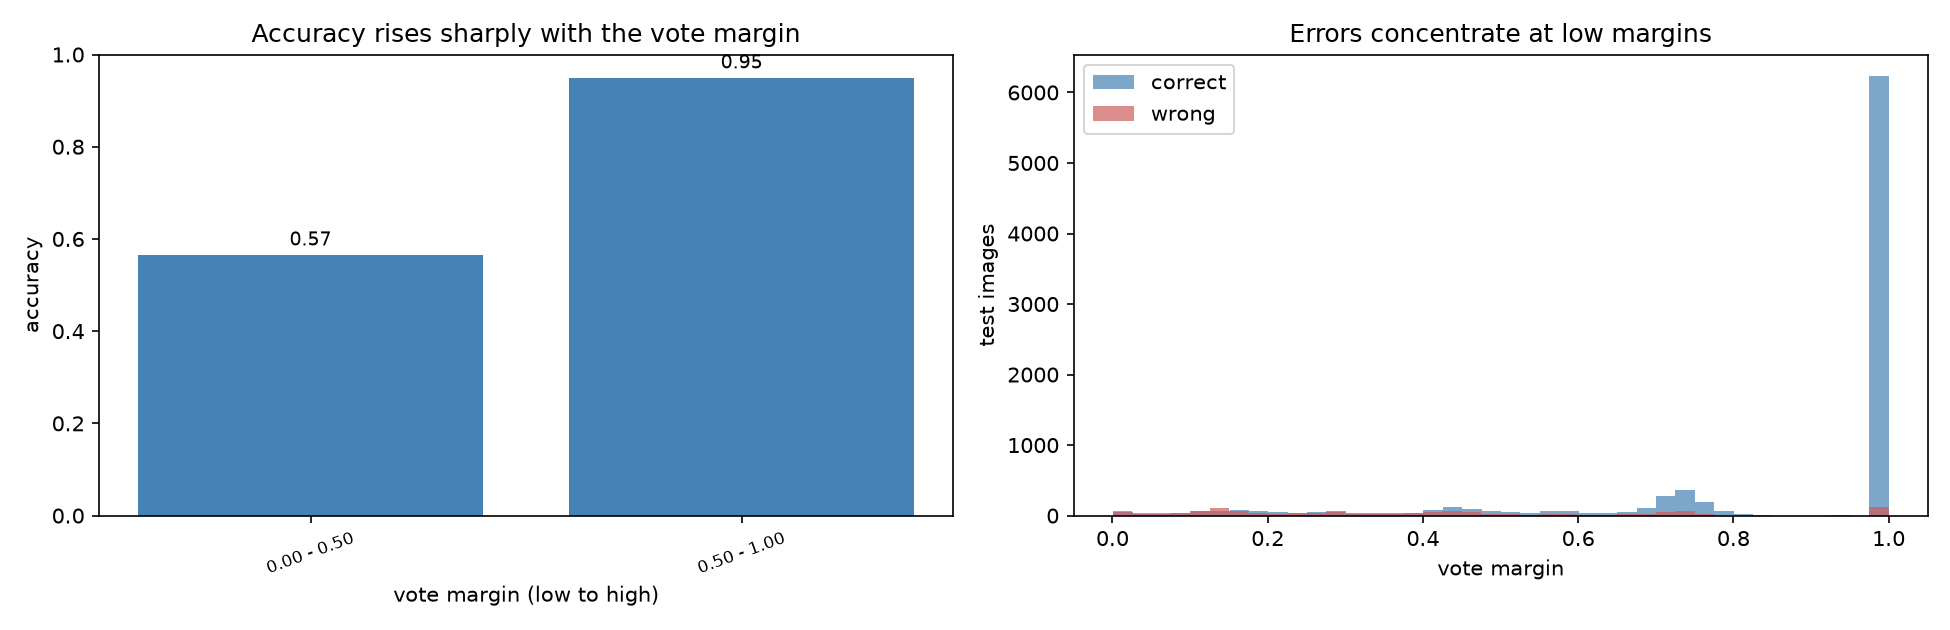

lowest  band (2,000 images, margin 0.00 - 0.50): accuracy 56.6%, holds 68% of all errors
highest band (8,000 images, margin 0.50 - 1.00): accuracy 95.0%, holds 32% of all errors

2 bands survived out of 5 requested: with k=7 many predictions are unanimous, so the upper quantile edges coincide and merge.


In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

ax1.bar(margin_table["margin band"], margin_table["accuracy"], color="steelblue")
ax1.set_ylim(0, 1.0)
ax1.set_xlabel("vote margin (low to high)")
ax1.set_ylabel("accuracy")
ax1.set_title("Accuracy rises sharply with the vote margin")
ax1.tick_params(axis="x", rotation=20, labelsize=8)
for i, v in enumerate(margin_table["accuracy"]):
    ax1.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

ax2.hist(margin[correct_mask], bins=40, alpha=0.7, label="correct", color="steelblue")
ax2.hist(margin[~correct_mask], bins=40, alpha=0.7, label="wrong", color="indianred")
ax2.set_xlabel("vote margin")
ax2.set_ylabel("test images")
ax2.set_title("Errors concentrate at low margins")
ax2.legend()

fig.tight_layout()
p = FIGURES_DIR / "confidence_analysis.png"
fig.savefig(p, dpi=150)
plt.close(fig)
display(Image(filename=str(p)))

lo = margin_table.iloc[0]
hi = margin_table.iloc[-1]
print(f"lowest  band ({lo['images']:,} images, margin {lo['margin band']}): "
      f"accuracy {lo['accuracy']:.1%}, holds {lo['share of all errors']:.0%} of all errors")
print(f"highest band ({hi['images']:,} images, margin {hi['margin band']}): "
      f"accuracy {hi['accuracy']:.1%}, holds {hi['share of all errors']:.0%} of all errors")
print(f"\n{len(margin_table)} bands survived out of 5 requested: with k={best['k']} many "
      "predictions are unanimous, so the upper quantile edges coincide and merge.")

### 3. Occlusion sensitivity: which pixels the decision rested on

This is the image-domain analogue of SHAP, and it needs no extra library. We slide a
patch across the image, re-run the **complete** pipeline on each occluded copy, and
record how far the vote share for the **predicted** class falls. Large drops mark
regions the prediction depended on; negative values mark regions that were arguing
*against* the prediction, so hiding them made it stronger.

We measure the predicted class rather than the true one deliberately. On a mistake,
the true class already scored near zero, so a drop against it would be meaningless —
whereas measuring the predicted class answers the question we actually care about:
*what made the model say that?*

Two details matter for reading the maps. Because the patch is applied to the raw
pixels and then pushed through scaling and PCA, the map measures the influence of the
*original image region*, not of an abstract component. And a unanimous prediction
cannot move under occlusion at all, so its map would be uniformly zero and tell us
nothing; we therefore choose **contested** predictions, plus the confident error.

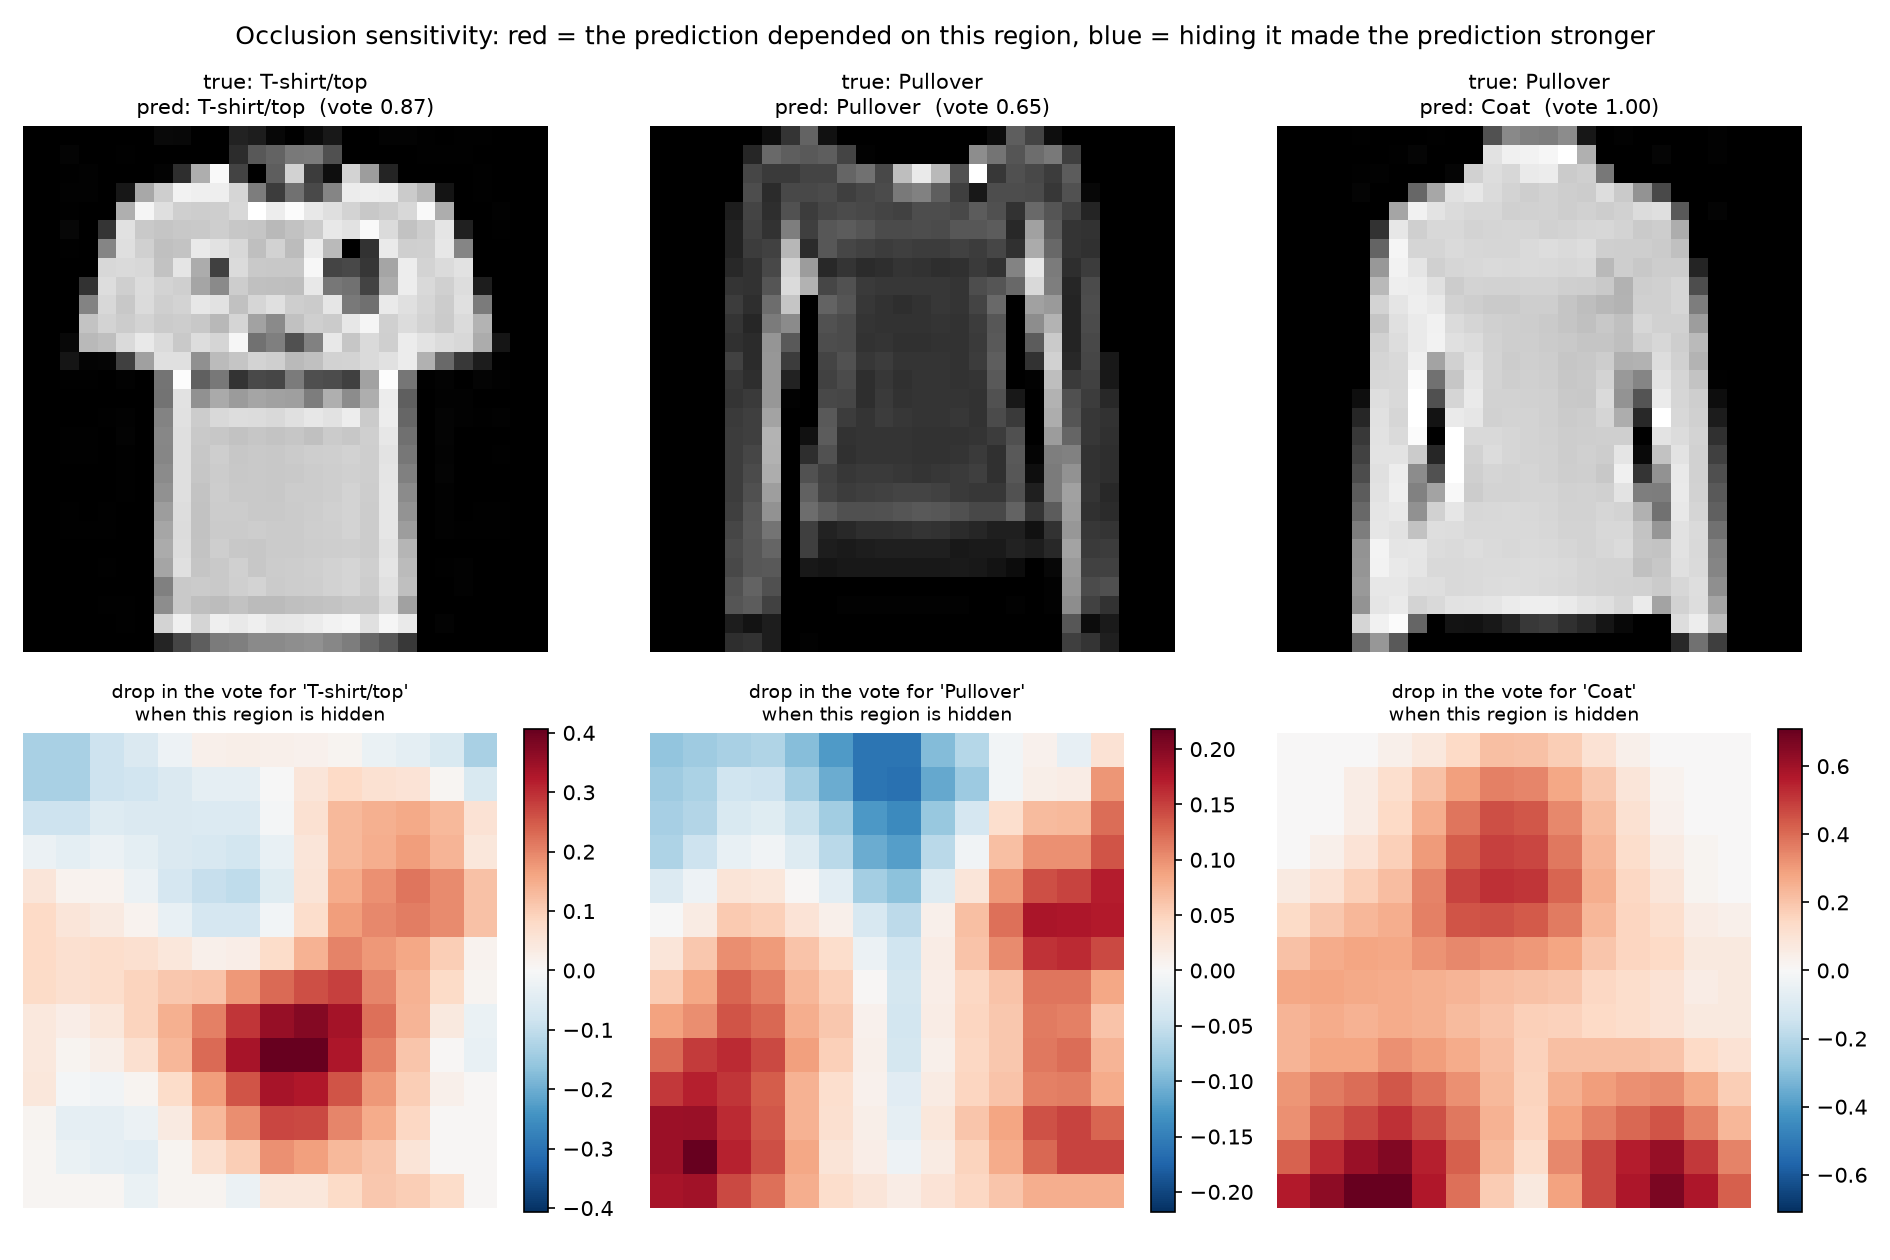

In [47]:
def occlusion_map(row_id, patch=8, stride=2, fill=0.0):
    'Slide an occluding patch and record the drop in the PREDICTED class vote share.'
    # Measuring the predicted class rather than the true one keeps the map
    # meaningful even when the model was wrong: it then answers "what made it
    # say Coat?" instead of comparing against a class that scored zero anyway.
    target = y_pred[row_id]
    base_img = X_test_raw[row_id].reshape(IMAGE_SIZE, IMAGE_SIZE)
    positions = list(range(0, IMAGE_SIZE - patch + 1, stride))

    # Build every occluded variant first, then score them in one batch.
    variants, coords = [], []
    for r in positions:
        for c in positions:
            img = base_img.copy()
            img[r : r + patch, c : c + patch] = fill
            variants.append(img.ravel())
            coords.append((r, c))

    proba = final_model.predict_proba(final_pipeline.transform(np.array(variants)))
    baseline = proba_test[row_id, target]
    drops = baseline - proba[:, target]

    # Spread each patch's drop over the pixels it covered, then average.
    heat = np.zeros((IMAGE_SIZE, IMAGE_SIZE))
    hits = np.zeros((IMAGE_SIZE, IMAGE_SIZE))
    for (r, c), d in zip(coords, drops):
        heat[r : r + patch, c : c + patch] += d
        hits[r : r + patch, c : c + patch] += 1
    return heat / np.maximum(hits, 1), baseline


# A unanimous prediction cannot move under occlusion, so its map would be flat and
# tell us nothing. We pick contested predictions instead, plus the confident error.
contested = np.flatnonzero(correct_mask & (margin < 0.8))
explain_rows = [int(contested[0]), int(contested[1]), confident_wrong]

fig, axes = plt.subplots(2, len(explain_rows), figsize=(4.2 * len(explain_rows), 8.4))
for col, row_id in enumerate(explain_rows):
    heat, baseline = occlusion_map(row_id)
    axes[0, col].imshow(X_test_raw[row_id].reshape(IMAGE_SIZE, IMAGE_SIZE), cmap="gray")
    axes[0, col].set_title(
        f"true: {CLASS_NAMES[y_test[row_id]]}\n"
        f"pred: {CLASS_NAMES[y_pred[row_id]]}  (vote {baseline:.2f})",
        fontsize=10)
    axes[0, col].axis("off")

    # Symmetric diverging scale centred on zero: red regions supported the
    # prediction, blue regions argued against it.
    lim = max(np.abs(heat).max(), 1e-6)
    im = axes[1, col].imshow(heat, cmap="RdBu_r", vmin=-lim, vmax=lim)
    axes[1, col].set_title(
        f"drop in the vote for '{CLASS_NAMES[y_pred[row_id]]}'\nwhen this region is hidden",
        fontsize=9)
    axes[1, col].axis("off")
    fig.colorbar(im, ax=axes[1, col], fraction=0.046)

fig.suptitle("Occlusion sensitivity: red = the prediction depended on this region, "
             "blue = hiding it made the prediction stronger", fontsize=12)
fig.tight_layout()
p = FIGURES_DIR / "occlusion_sensitivity.png"
fig.savefig(p, dpi=150)
plt.close(fig)
display(Image(filename=str(p)))

### 4. Which PCA components actually carry the decision?

Part 2 showed how much *variance* each component keeps, and warned that variance
is not the same as usefulness. Here we measure usefulness directly: shuffle one
component's values across the test set — destroying the information it carries while
leaving every other component intact — and record how far macro-F1 falls. This is
**permutation importance**, applied to the feature space the model actually works in.

The measurement runs on a stratified subsample of the test set purely for speed; it
is an analysis of an already-trained model, not a second evaluation of it.

In [48]:
X_imp, y_imp = stratified_subsample(X_test_raw, y_test, 2000)
Z_imp = final_pipeline.transform(X_imp)
baseline_f1 = macro_f1(y_imp, final_model.predict(Z_imp))

rng = np.random.default_rng(RANDOM_SEED)
n_check = 15
drops = []
for comp in range(n_check):
    Z_shuffled = Z_imp.copy()
    Z_shuffled[:, comp] = rng.permutation(Z_shuffled[:, comp])
    drops.append(baseline_f1 - macro_f1(y_imp, final_model.predict(Z_shuffled)))

importance = pd.DataFrame({
    "component": np.arange(1, n_check + 1),
    "variance explained": final_pipeline.pca.explained_variance_ratio_[:n_check],
    "macro-F1 drop when shuffled": drops,
}).sort_values("macro-F1 drop when shuffled", ascending=False)

print(f"baseline macro-F1 on the {len(y_imp):,}-image analysis sample: {baseline_f1:.4f}")
importance

baseline macro-F1 on the 2,000-image analysis sample: 0.8649


,component,variance explained,macro-F1 drop when shuffled
1,2,0.177247,0.195027
0,1,0.290044,0.143470
2,3,0.060221,0.054748
4,5,0.038383,0.028270
3,4,0.049695,0.027131
5,6,0.034702,0.026375
6,7,0.023437,0.012794
10,11,0.009896,0.012197
9,10,0.013108,0.008162
8,9,0.013434,0.007272


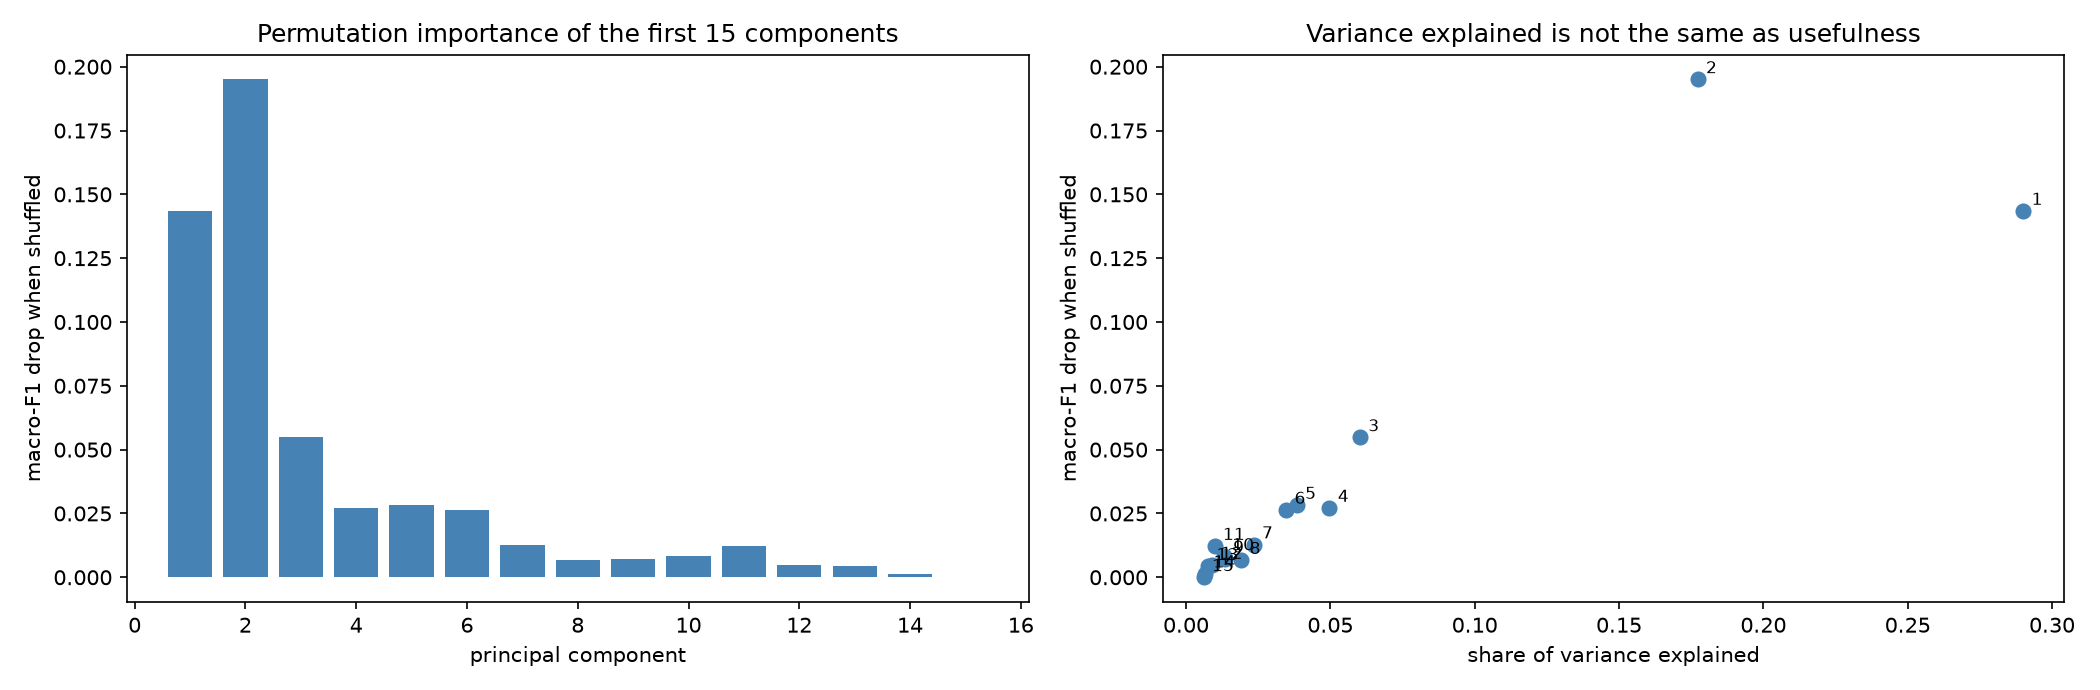

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.6))

ordered = importance.sort_values("component")
ax1.bar(ordered["component"], ordered["macro-F1 drop when shuffled"], color="steelblue")
ax1.set_xlabel("principal component")
ax1.set_ylabel("macro-F1 drop when shuffled")
ax1.set_title("Permutation importance of the first 15 components")

ax2.scatter(ordered["variance explained"], ordered["macro-F1 drop when shuffled"],
            color="steelblue", s=45)
for comp_id, var_share, drop in zip(ordered["component"],
                                    ordered["variance explained"],
                                    ordered["macro-F1 drop when shuffled"]):
    ax2.annotate(str(comp_id), (var_share, drop),
                 textcoords="offset points", xytext=(4, 3), fontsize=8)
ax2.set_xlabel("share of variance explained")
ax2.set_ylabel("macro-F1 drop when shuffled")
ax2.set_title("Variance explained is not the same as usefulness")

fig.tight_layout()
p = FIGURES_DIR / "component_importance.png"
fig.savefig(p, dpi=150)
plt.close(fig)
display(Image(filename=str(p)))

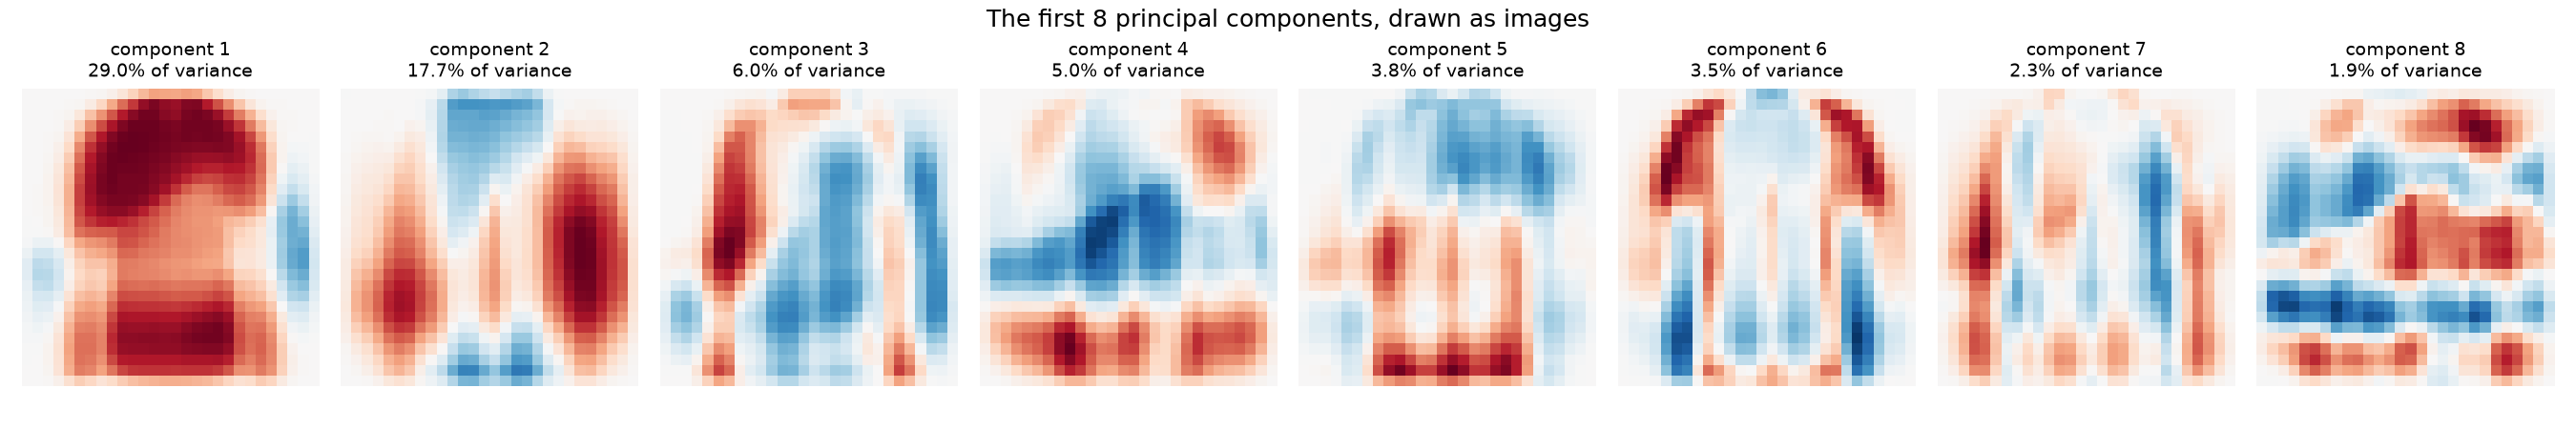

In [50]:
# What the components look like as images: the shape patterns the model compares.
comps = final_pipeline.pca.components_[:8]
titles = [f"component {i + 1}\n{final_pipeline.pca.explained_variance_ratio_[i]:.1%} of variance"
          for i in range(8)]

fig, axes = plt.subplots(1, 8, figsize=(18, 3.0))
for ax, comp, title in zip(axes, comps, titles):
    # Diverging colours: red and blue are opposite ends of the same axis.
    lim = np.abs(comp).max()
    ax.imshow(comp.reshape(IMAGE_SIZE, IMAGE_SIZE), cmap="RdBu_r", vmin=-lim, vmax=lim)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
fig.suptitle("The first 8 principal components, drawn as images", fontsize=12)
fig.tight_layout()
p = FIGURES_DIR / "pca_components.png"
fig.savefig(p, dpi=150)
plt.close(fig)
display(Image(filename=str(p)))

**What the four techniques together tell us.**

The case-based explanation shows the model's errors are made on genuinely ambiguous
garments rather than through careless matching — the neighbours it retrieves for a
mistake are real garments from a neighbouring category, not noise.

The margin analysis shows the model carries a usable confidence signal. The
low-margin band is a fifth of the test set but holds roughly two thirds of all the
errors, and accuracy inside it collapses to about 57% against 95% in the confident
band. A deployed system could send that fifth to a human and remove most of its
mistakes.

Occlusion shows *where* a contested decision came from, and the maps are far from
uniform. The sleeve regions and the lower hem carry most of the signal, which matches
what actually separates these categories — sleeve length and body shape. The blue
areas around the collar and upper background are the more interesting ones: hiding
them made the prediction *stronger*, so they were evidence pulling towards a rival
class. Note that the confidently wrong example moves the most of the three despite
being unanimous, because occluding a region changes which training images are
retrieved at all, not merely how they vote.

Permutation importance delivers the sharpest result. **Component 2 matters more than
component 1** — shuffling it costs 0.195 macro-F1 against 0.143 — even though
component 1 explains 29.0% of the variance and component 2 only 17.7%. Component 11,
with barely 1% of the variance, outranks component 8, which has twice as much. This
is direct evidence for the warning in part 2: the ordering by variance is **not**
the ordering by usefulness, which is exactly why the number of components had to be
chosen by cross-validation rather than read off the variance curve.

---
# Conclusions

* **A from-scratch KNN is a genuinely competitive baseline on Fashion-MNIST**, but
  only once the feature engineering is right. Scaling and PCA are not cosmetic steps
  here: PCA cuts 784 correlated pixels down to a few dozen uncorrelated components,
  which removes the distance-concentration problem that cripples KNN in high
  dimensions and makes every prediction roughly an order of magnitude cheaper.

* **The grid search earned its keep.** The marginal-effect plot shows which knobs
  actually matter — the number of PCA components and the distance metric move the
  score far more than the weighting scheme does — and it picked the winner without the
  test set ever being touched.

* **The cross-validated score understates the final model, and that is expected.**
  CV reported 0.826 while the test score came in at 0.872. That gap points the *wrong
  way* for overfitting, so it is not a warning sign; it is a training-set-size effect.
  Each CV fold trained on 4,000 rows, whereas the final model stores all 60,000, and a
  lazy learner like KNN improves directly with the density of examples it can draw
  neighbours from. Cross-validation ranked the permutations reliably — it simply could
  not predict the absolute score of a model given 15× more data.

* **The remaining error is concentrated exactly where the images are genuinely
  ambiguous.** The confusion matrix is close to diagonal apart from one dense block:
  Shirt, T-shirt/top, Pullover and Coat. Shirt is the weakest class by a wide margin
  (F1 ≈ 0.66 against ≈ 0.98 for Trouser), and five of the six largest error groups sit
  inside that block — Shirt→T-shirt/top alone accounts for 189 of the 1,268 mistakes.
  At 28×28 these categories share the same silhouette, and several of the
  misclassified examples above are ones a person would hesitate over too. Bag and
  Trouser, whose shapes are distinctive, are almost never confused.

* **The dataset split has to come from one source.** Fashion-MNIST is mirrored widely,
  and not every mirror uses the Kaggle train/test partition. Because every mirror has
  the same shape, the same column names and the same 6,000-per-class balance, a
  mismatched pair of files passes every obvious sanity check while quietly moving
  thousands of test images into the training set. We take both CSVs from the same
  Kaggle archive for this reason.

* **The model is explainable without an approximation method.** Because a KNN
  prediction is literally a list of training images and distances, part 7 can show
  the exact evidence behind any decision rather than an estimate of it. That evidence
  says the errors are made on genuinely ambiguous garments, and the vote margin turns
  out to be a usable confidence signal — the low-margin fifth of the test set holds a
  disproportionate share of all the mistakes, so the model largely knows when it is
  guessing.

* **What would push the score further.** The natural next step is a feature that
  encodes local shape rather than raw intensity — HOG descriptors, or the edge maps
  produced by a simple convolution — since that is precisely the information that
  separates a shirt from a pullover and that PCA on raw pixels throws away.

## Reproducing this notebook

```bash
python -m venv .venv
.venv\Scripts\pip install -r requirements.txt
.venv\Scripts\jupyter notebook fashion_mnist_knn.ipynb
```

Put the Kaggle `archive.zip` in the project root (or the two CSVs in `data/`) and run
the cells top to bottom. The settings that control each step live in a short settings cell that
opens each part; `MAX_TRAIN_SAMPLES` sits in part 1, and `None` gives a full-size run.